# Puff-evoked CS–Vm population analysis

This exploratory notebook asks whether Purkinje cells that co-vary in their complex-spike (CS) responses to air puffs also co-vary in their subthreshold/Vm responses.

Each puff onset is the **rising edge** whose first row has `Arduino_State == 1`. Imaging sessions and behavior CSVs are matched by their shared `puff_N` recording number. The workflow separates:

- mean evoked responses of individual PCs;
- trial-by-trial CS and Vm response coupling between PC pairs;
- baseline versus puff-response correlation matrices;
- matrix-level CS–Vm correspondence using node-label/QAP permutation;
- locomotion/velocity changes as a possible common-state covariate;
- spatial response maps when ROI coordinates are available.

Pairwise Pearson values are descriptive. Pair-level shuffle null95 and FDR are shown, but CS–Vm matrix correspondence is inferred with QAP because PC pairs share nodes.


In [1]:
import os
import re
import glob
import json
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from scipy.ndimage import median_filter
from scipy.signal import butter, sosfiltfilt
from scipy.cluster.hierarchy import fcluster, linkage, leaves_list, optimal_leaf_ordering
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr, rankdata, spearmanr
from IPython.display import display

# ==============================
# SETTINGS
# ==============================
DATA_FOLDER = r'/Users/liangqiyuan/Desktop/Temp_data/20260810_A74_Microzones_puff'
SESSION_GLOB = 'spike_detection/*_analyzed.npz'
BEHAVIOR_GLOB = 'Behavior/*.csv'
STRICT_CELL_NAME_MATCH = True

# 1. Puff detection and aligned windows
PUFF_CONFIG = {
    'state_column': 'Arduino_State',
    'state_on_value': 1,
    'time_column': 'Time_s',
    'aligned_window_ms': (-1000.0, 1500.0),
    'baseline_ms': (-800.0, -100.0),
    'matched_baseline_ms': (-400.0, -100.0),
    'pseudo_baseline_reference_ms': (-800.0, -500.0),
    'cs_response_ms': (0.0, 300.0),
    'vm_early_response_ms': (0.0, 300.0),
    'vm_late_response_ms': (300.0, 1000.0),
    'peth_bin_ms': 50.0,
}
# Every rising edge is one puff. Matched 300 ms baseline and response windows are used for
# trial-by-trial pair matrices; the longer baseline stabilizes per-trial Vm normalization.

# 2. Subthreshold/Vm preprocessing (kept consistent with microzone.ipynb)
PREPROCESS_CONFIG = {
    'bleach_median_window_ms': 1000.0,
    'spike_mask_ss_ms': (-2.0, 3.0),
    'spike_mask_cs_ms': (-8.0, 16.0),
    'second_median_enabled': True,
    'second_median_window_ms': 10.0,
    'lowpass_enabled': True,
    'lowpass_cutoff_hz': 100.0,
    'lowpass_order': 2,
}
# Sign convention: +1 preserves the saved fluorescence polarity; -1 flips negative-going
# fluorescence so upward means a depolarizing-direction Vm proxy. The supplied A74 files
# declare NEGATIVE_GOING=true, so with the current +1 setting, upward means brighter native
# fluorescence (the opposite direction from the downward CS/depolarizing deflections).
VM_SIGN_MULTIPLIER = 1.0

# 3. Statistics and pairwise trial coupling
STATS_CONFIG = {
    'n_sign_flips': 10000,
    'n_pair_trial_shuffles': 1000,
    'n_qap_permutations': 10000,
    'fdr_alpha': 0.05,
    'rng_seed': 2074,
    'demean_trial_responses_within_session': True,
}
# Sign flips test paired puff-versus-baseline changes per cell. Pair trial shuffles break
# trial identity for one PC. Before pair correlations, each PC is demeaned within session so recording-level shifts do not masquerade as trial coupling. QAP permutes whole PC identities when comparing CS and Vm matrices.

# 4. Baseline + puff-evoked clustering
CLUSTER_CONFIG = {
    'baseline_weight': 0.50,
    'puff_weight': 0.50,
    'k_min': 2,
    'k_max': 6,
    'min_cluster_size': 2,
    'linkage_method': 'average',
    'baseline_exclude_around_puff_ms': (-500.0, 1500.0),
    'baseline_cs_bin_ms': 50.0,
    'baseline_vm_sample_ms': 10.0,
    'n_bootstrap': 300,
    'bootstrap_block_ms': 1000.0,
    'rng_seed': 3817,
}
# Baseline matrices use whole-recording activity after excluding -500 to +1500 ms around
# every puff. CS baseline uses 50-ms spike-count bins; Vm baseline uses the CS/SS-blanked,
# low-pass trace sampled every 10 ms. Puff matrices use within-session residual trial
# responses. Each matrix is standardized across pairs before the weighted combination, so
# 0.5/0.5 means equal influence rather than whichever matrix has the larger raw variance.
# k is selected from 2-6 by the highest silhouette, subject to at least two PCs per cluster.
# Block/trial bootstrap co-assignment is descriptive stability evidence, not a p-value.

# 5. Display/export
CORR_HEATMAP_SCALE = {'vmin': -0.60, 'vmax': 0.60, 'center': 0.0}
OUTPUT_CONFIG = {'table_top_n': 14, 'scatter_label_top_n': 8}
EXPORT_RESULTS = False
EXPORT_DIR = os.path.join(DATA_FOLDER, 'puff_cs_vm_exports')

sns.set_theme(style='white', context='talk')
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': False,
                     'figure.dpi': 120, 'svg.fonttype': 'none'})

def display_top(df, label=None, sort_by=None, ascending=False, n=None):
    n = int(OUTPUT_CONFIG['table_top_n'] if n is None else n)
    view = df.sort_values(sort_by, ascending=ascending) if sort_by is not None and len(df) else df
    if label: print(f'{label}: showing {min(n, len(view))} of {len(view)} rows')
    display(view.head(n))


## Parameter guide

`aligned_window_ms` controls the displayed event window. CS response is summarized over 0–300 ms, matching the earlier synchrony analyses. Vm is reported separately over 0–300 ms and 300–1000 ms. Per-trial Vm responses are baseline-subtracted and divided by that trial's baseline SD, so values are baseline SD units rather than ΔF/F.

The primary pair analysis correlates responses **across puff trials**. Thus, a high CS pair value means two PCs tend to have strong or weak CS responses on the same puffs; a high Vm pair value means their puff-evoked Vm amplitudes fluctuate together across trials. This is different from correlating their continuous traces over the whole recording.

Pairwise trial coupling is calculated after subtracting each PC's mean response within each recording. The resulting matrices therefore emphasize puff-to-puff co-fluctuations (noise correlation) rather than differences between recording sessions.

**Combined clustering:** separate CS and Vm solutions combine equal-weight baseline and puff-response evidence. Whole-recording baseline excludes puff-contaminated windows; the puff component measures within-session trial-to-trial coupling. Each component is pair-standardized before averaging. `k` is the number of candidate clusters and is selected by silhouette from 2–6, while rejecting solutions containing singleton clusters when possible. Co-assignment shows how often each pair stays together after block/trial bootstrap resampling.


Loaded 3 sessions, 14 shared PCs, and 18 puff trials.


,session,behavior_csv,duration_s,n_puffs,puff_onsets_s,CS_total,SS_total
0,puff_2_MUnit_15,A74_puff_2_20260810_171108.csv,29.9997,6,"4.838, 7.498, 11.940, 16.443, 20.369, 24.230",237,0
1,puff_3_MUnit_18,A74_puff_3_20260810_171400.csv,29.9997,6,"4.520, 8.559, 12.031, 15.741, 20.048, 24.894",254,0
2,puff_4_MUnit_20,A74_puff_4_20260810_171553.csv,29.9997,6,"3.645, 8.381, 11.124, 15.560, 20.536, 24.751",243,0


Polarity: files are NEGATIVE_GOING and VM_SIGN_MULTIPLIER=+1 (no inversion). Upward in Vm panels is brighter native fluorescence, opposite the downward depolarizing/CS direction.


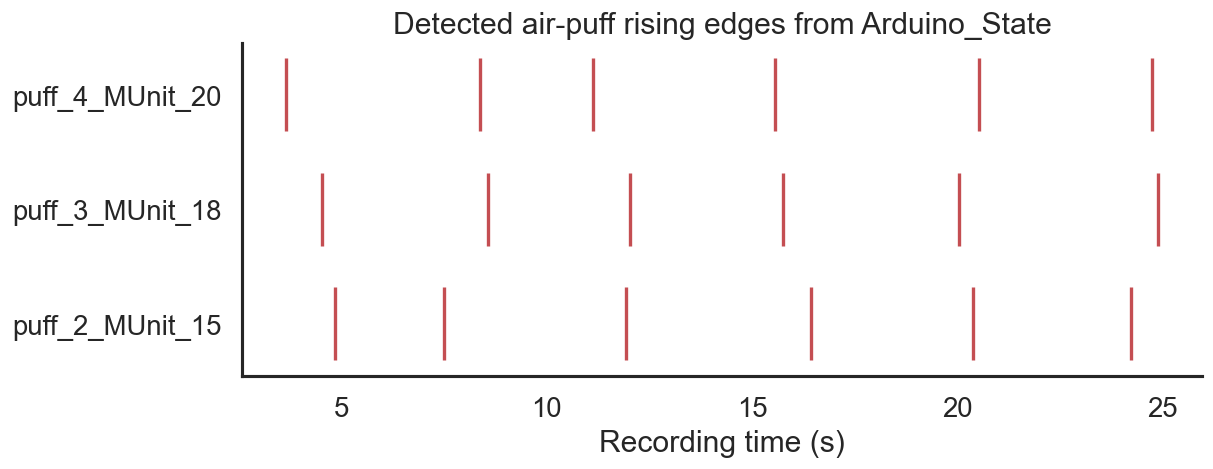

In [2]:
# ==============================
# LOAD IMAGING SESSIONS AND MATCH BEHAVIOR CSVs
# ==============================
def _events_by_cell(value, n_cells):
    arr = np.asarray(value, dtype=object)
    if arr.ndim >= 2 and arr.shape[0] == n_cells and arr.shape[1] == 0:
        return [np.array([], dtype=float) for _ in range(n_cells)]
    out = []
    for idx in range(n_cells):
        try: values = np.asarray(arr[idx], dtype=float).reshape(-1)
        except Exception: values = np.array([], dtype=float)
        out.append(values[np.isfinite(values)])
    return out

def _recording_number(name):
    match = re.search(r'(?:^|[_-])puff[_-]?(\d+)(?:[_-]|$)', str(name), flags=re.I)
    return int(match.group(1)) if match else None

def _detect_puff_onsets(csv_path, cfg):
    df = pd.read_csv(csv_path)
    state = pd.to_numeric(df[cfg['state_column']], errors='coerce').to_numpy()
    time_s = pd.to_numeric(df[cfg['time_column']], errors='coerce').to_numpy()
    on = np.isfinite(state) & np.isfinite(time_s) & (state == float(cfg['state_on_value']))
    rising = np.flatnonzero(on & ~np.r_[False, on[:-1]])
    return time_s[rising].astype(float) * 1000.0, df

session_paths = sorted(glob.glob(os.path.join(DATA_FOLDER, SESSION_GLOB)))
behavior_paths = sorted(glob.glob(os.path.join(DATA_FOLDER, BEHAVIOR_GLOB)))
if not session_paths: raise FileNotFoundError(f'No NPZ sessions matched {SESSION_GLOB!r} in {DATA_FOLDER}')

behavior_by_number = {_recording_number(os.path.basename(path)): path for path in behavior_paths
                      if _recording_number(os.path.basename(path)) is not None}
sessions = []
reference_names = None
for path in session_paths:
    with np.load(path, allow_pickle=True) as npz:
        time_ms = np.asarray(npz['time_ms'], float).reshape(-1)
        raw_data = np.asarray(npz['raw_data'], float)
        cell_names_here = [str(x) for x in np.asarray(npz['cell_names']).reshape(-1)]
        fs = float(np.asarray(npz['fs']).reshape(-1)[0])
        n_cells_here = raw_data.shape[1]
        cs = _events_by_cell(npz['spike_times_cs'], n_cells_here)
        ss = _events_by_cell(npz['spike_times_ss'], n_cells_here)
        detection_metadata = {}
        for metadata_key in ('analysis_settings_json', 'detection_params_json'):
            if metadata_key in npz.files:
                try:
                    detection_metadata.update(json.loads(str(np.asarray(npz[metadata_key]).item())))
                except (TypeError, ValueError, json.JSONDecodeError):
                    pass
        negative_going = detection_metadata.get('negative_going', detection_metadata.get('NEGATIVE_GOING'))
        if negative_going is None and isinstance(detection_metadata.get('params'), dict):
            negative_going = detection_metadata['params'].get('NEGATIVE_GOING')
    if raw_data.shape[0] != len(time_ms): raise ValueError(f'Time/raw length mismatch: {path}')
    if reference_names is None: reference_names = cell_names_here
    elif STRICT_CELL_NAME_MATCH and cell_names_here != reference_names:
        raise ValueError(f'Cell names differ in {os.path.basename(path)}')
    number = _recording_number(os.path.basename(path))
    behavior_path = behavior_by_number.get(number)
    if behavior_path is None: raise FileNotFoundError(f'No Behavior CSV matched recording puff_{number}: {path}')
    puff_times_ms, behavior_df = _detect_puff_onsets(behavior_path, PUFF_CONFIG)
    sessions.append({'session_name': os.path.basename(path).replace('_analyzed.npz', ''),
                     'npz_path': path, 'behavior_path': behavior_path, 'recording_number': number,
                     'time_ms': time_ms, 'raw_data': raw_data, 'cell_names': cell_names_here,
                     'n_cells': n_cells_here, 'fs': fs, 'spike_times_cs': cs, 'spike_times_ss': ss,
                     'puff_times_ms': puff_times_ms, 'behavior_df': behavior_df,
                     'negative_going': None if negative_going is None else bool(negative_going)})

cell_names = reference_names; n_cells = len(cell_names)
session_summary = pd.DataFrame([{
    'session': s['session_name'], 'behavior_csv': os.path.basename(s['behavior_path']),
    'duration_s': (s['time_ms'][-1] - s['time_ms'][0]) / 1000.0,
    'n_puffs': len(s['puff_times_ms']), 'puff_onsets_s': ', '.join(f'{x/1000:.3f}' for x in s['puff_times_ms']),
    'CS_total': sum(len(x) for x in s['spike_times_cs']), 'SS_total': sum(len(x) for x in s['spike_times_ss']),
} for s in sessions])
print(f'Loaded {len(sessions)} sessions, {n_cells} shared PCs, and {sum(len(s["puff_times_ms"]) for s in sessions)} puff trials.')
display(session_summary)
if int(session_summary['SS_total'].sum()) == 0:
    print('Warning: no SS events are present; Vm preprocessing can mask CS but cannot remove undetected SS waveforms.')
polarity_values = [s['negative_going'] for s in sessions if s['negative_going'] is not None]
all_negative_going = bool(polarity_values) and all(polarity_values)
if all_negative_going and VM_SIGN_MULTIPLIER == 1.0:
    print('Polarity: files are NEGATIVE_GOING and VM_SIGN_MULTIPLIER=+1 (no inversion). '
          'Upward in Vm panels is brighter native fluorescence, opposite the downward depolarizing/CS direction.')
elif all_negative_going and VM_SIGN_MULTIPLIER == -1.0:
    print('Polarity: negative-going fluorescence is inverted; upward in Vm panels is the depolarizing direction.')
else:
    print(f'Polarity: VM_SIGN_MULTIPLIER={VM_SIGN_MULTIPLIER:+g}; confirm indicator polarity from acquisition metadata.')

fig, ax = plt.subplots(figsize=(10, 3.8), constrained_layout=True)
for row, s in enumerate(sessions):
    ax.vlines(s['puff_times_ms'] / 1000.0, row - 0.32, row + 0.32, color='#C44E52', lw=2)
ax.set_yticks(range(len(sessions)), [s['session_name'] for s in sessions]); ax.set_xlabel('Recording time (s)')
ax.set_title('Detected air-puff rising edges from Arduino_State'); sns.despine(ax=ax); plt.show(); plt.close(fig)


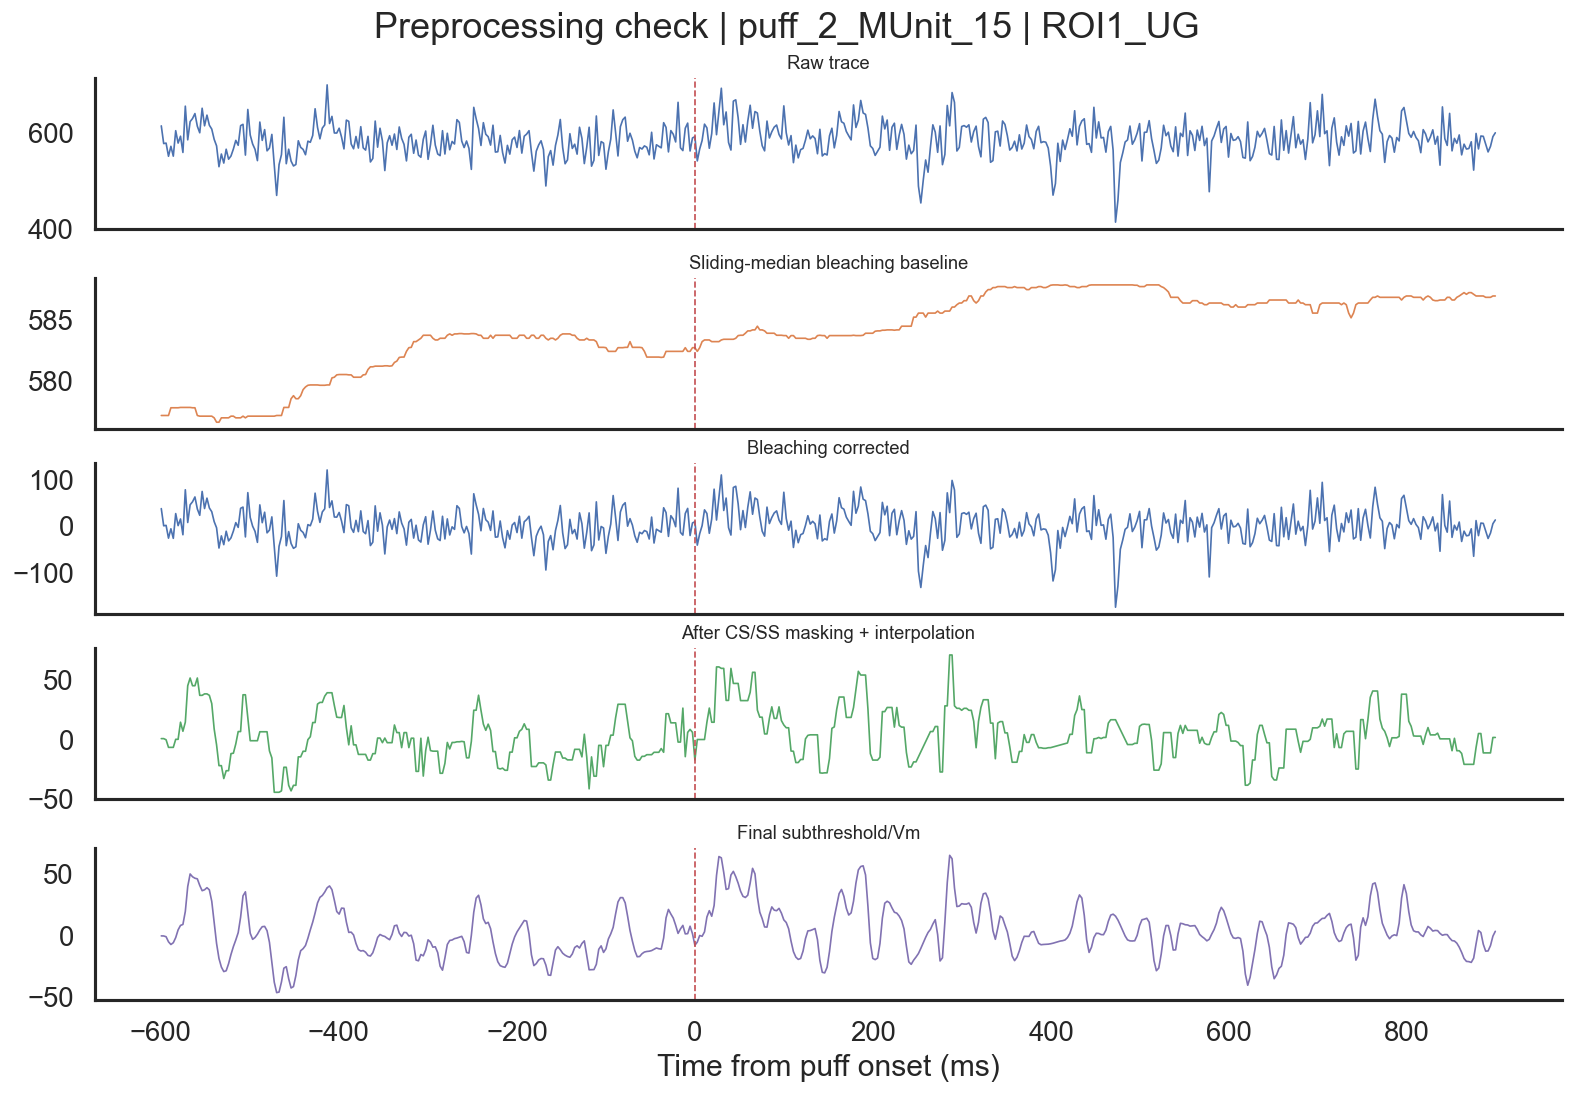

In [3]:
# ==============================
# SUBTHRESHOLD / Vm PREPROCESSING
# ==============================
def _odd_samples(window_ms, fs, minimum=1):
    size = max(int(minimum), int(round(float(window_ms) * float(fs) / 1000.0)))
    return size if size % 2 else size + 1

def _mask_and_interpolate(trace, time_ms, ss_times, cs_times, cfg):
    trace = np.asarray(trace, float); masked = trace.copy(); mask = np.zeros(len(trace), bool)
    for events, window in [(ss_times, cfg['spike_mask_ss_ms']), (cs_times, cfg['spike_mask_cs_ms'])]:
        for event in np.asarray(events, float): mask |= (time_ms >= event + window[0]) & (time_ms <= event + window[1])
    good = np.isfinite(masked) & ~mask
    if np.sum(good) >= 2: masked[mask] = np.interp(time_ms[mask], time_ms[good], masked[good])
    else: masked[mask] = np.nan
    return masked

processed_sessions = []
for s in sessions:
    fs = float(s['fs']); raw = np.asarray(s['raw_data'], float); t = s['time_ms']
    baseline = median_filter(raw, size=(_odd_samples(PREPROCESS_CONFIG['bleach_median_window_ms'], fs, 3), 1), mode='nearest')
    corrected = raw - baseline
    despiked = np.empty_like(corrected)
    for cell in range(n_cells):
        despiked[:, cell] = _mask_and_interpolate(corrected[:, cell], t, s['spike_times_ss'][cell], s['spike_times_cs'][cell], PREPROCESS_CONFIG)
    if PREPROCESS_CONFIG['second_median_enabled']:
        despiked = median_filter(despiked, size=(_odd_samples(PREPROCESS_CONFIG['second_median_window_ms'], fs, 3), 1), mode='nearest')
    subthreshold = despiked.copy()
    if PREPROCESS_CONFIG['lowpass_enabled']:
        nyq = 0.5 * fs; cutoff = min(float(PREPROCESS_CONFIG['lowpass_cutoff_hz']), 0.95 * nyq)
        sos = butter(int(PREPROCESS_CONFIG['lowpass_order']), cutoff / nyq, btype='lowpass', output='sos')
        subthreshold = sosfiltfilt(sos, subthreshold, axis=0)
    out = dict(s); out.update({'baseline': baseline, 'corrected': corrected, 'despiked': despiked,
                               'subthreshold': float(VM_SIGN_MULTIPLIER) * subthreshold})
    processed_sessions.append(out)

# One bounded preprocessing example around the first puff.
s = processed_sessions[0]; event = s['puff_times_ms'][0]; mask = (s['time_ms'] >= event - 600) & (s['time_ms'] <= event + 900)
fig, axes = plt.subplots(5, 1, figsize=(13, 9), sharex=True, constrained_layout=True)
for ax, key, title, color in zip(axes,
    ['raw_data', 'baseline', 'corrected', 'despiked', 'subthreshold'],
    ['Raw trace', 'Sliding-median bleaching baseline', 'Bleaching corrected', 'After CS/SS masking + interpolation', 'Final subthreshold/Vm'],
    ['#4C72B0', '#DD8452', '#4C72B0', '#55A868', '#8172B2']):
    ax.plot(s['time_ms'][mask] - event, s[key][mask, 0], color=color, lw=1.0); ax.set_title(title, fontsize=11); ax.axvline(0, color='#C44E52', ls='--', lw=1)
axes[-1].set_xlabel('Time from puff onset (ms)'); fig.suptitle(f'Preprocessing check | {s["session_name"]} | {cell_names[0]}')
plt.show(); plt.close(fig)


In [4]:
# ==============================
# EXTRACT PUFF-ALIGNED CS AND Vm TRIALS
# ==============================
def _window_mask(grid, window): return (grid >= float(window[0])) & (grid < float(window[1]))

fs_ref = float(np.median([s['fs'] for s in processed_sessions]))
dt_ms = 1000.0 / fs_ref
aligned_grid_ms = np.arange(PUFF_CONFIG['aligned_window_ms'][0], PUFF_CONFIG['aligned_window_ms'][1] + 0.5 * dt_ms, dt_ms)
base_mask = _window_mask(aligned_grid_ms, PUFF_CONFIG['baseline_ms'])
matched_base_mask = _window_mask(aligned_grid_ms, PUFF_CONFIG['matched_baseline_ms'])
pseudo_ref_mask = _window_mask(aligned_grid_ms, PUFF_CONFIG['pseudo_baseline_reference_ms'])
vm_early_mask = _window_mask(aligned_grid_ms, PUFF_CONFIG['vm_early_response_ms'])
vm_late_mask = _window_mask(aligned_grid_ms, PUFF_CONFIG['vm_late_response_ms'])

vm_trial_z = []; vm_trial_native = []; cs_response_counts = []; cs_baseline_counts = []; trial_metadata = []
for s in processed_sessions:
    behavior = s['behavior_df']; behavior_t_ms = pd.to_numeric(behavior[PUFF_CONFIG['time_column']], errors='coerce').to_numpy(float) * 1000.0
    velocity_col = next((c for c in behavior.columns if str(c).strip().lower() == 'smoothed_vel_cm_s'), None)
    velocity = pd.to_numeric(behavior[velocity_col], errors='coerce').to_numpy(float) if velocity_col else np.full(len(behavior), np.nan)
    for event_idx, event_ms in enumerate(s['puff_times_ms'], start=1):
        absolute_grid = event_ms + aligned_grid_ms
        if absolute_grid[0] < s['time_ms'][0] or absolute_grid[-1] > s['time_ms'][-1]: continue
        native = np.column_stack([np.interp(absolute_grid, s['time_ms'], s['subthreshold'][:, cell]) for cell in range(n_cells)])
        base_mean = np.nanmean(native[base_mask], axis=0); base_sd = np.nanstd(native[base_mask], axis=0, ddof=1)
        base_sd[~np.isfinite(base_sd) | (base_sd <= 1e-12)] = 1.0
        vm_trial_native.append(native - base_mean); vm_trial_z.append((native - base_mean) / base_sd)
        response_counts = []; baseline_counts = []
        for spikes in s['spike_times_cs']:
            response_counts.append(np.sum((spikes >= event_ms + PUFF_CONFIG['cs_response_ms'][0]) & (spikes < event_ms + PUFF_CONFIG['cs_response_ms'][1])))
            baseline_counts.append(np.sum((spikes >= event_ms + PUFF_CONFIG['matched_baseline_ms'][0]) & (spikes < event_ms + PUFF_CONFIG['matched_baseline_ms'][1])))
        cs_response_counts.append(response_counts); cs_baseline_counts.append(baseline_counts)
        vel_base = np.nanmean(velocity[(behavior_t_ms >= event_ms + PUFF_CONFIG['baseline_ms'][0]) & (behavior_t_ms < event_ms + PUFF_CONFIG['baseline_ms'][1])])
        vel_resp = np.nanmean(velocity[(behavior_t_ms >= event_ms) & (behavior_t_ms < event_ms + PUFF_CONFIG['vm_late_response_ms'][1])])
        trial_metadata.append({'session': s['session_name'], 'puff_index': event_idx, 'onset_ms': event_ms,
                               'velocity_baseline_cm_s': vel_base, 'velocity_response_cm_s': vel_resp,
                               'velocity_delta_cm_s': vel_resp - vel_base})

vm_trial_z = np.asarray(vm_trial_z, float); vm_trial_native = np.asarray(vm_trial_native, float)
cs_response_counts = np.asarray(cs_response_counts, float); cs_baseline_counts = np.asarray(cs_baseline_counts, float)
trial_metadata_df = pd.DataFrame(trial_metadata); n_trials = len(trial_metadata_df)
vm_early_response = np.nanmean(vm_trial_z[:, vm_early_mask, :], axis=1)
vm_late_response = np.nanmean(vm_trial_z[:, vm_late_mask, :], axis=1)
vm_pseudo_baseline = np.nanmean(vm_trial_z[:, matched_base_mask, :], axis=1) - np.nanmean(vm_trial_z[:, pseudo_ref_mask, :], axis=1)
cs_window_s = (PUFF_CONFIG['cs_response_ms'][1] - PUFF_CONFIG['cs_response_ms'][0]) / 1000.0
cs_base_window_s = (PUFF_CONFIG['matched_baseline_ms'][1] - PUFF_CONFIG['matched_baseline_ms'][0]) / 1000.0
cs_delta_rate_trials = cs_response_counts / cs_window_s - cs_baseline_counts / cs_base_window_s
print(f'Extracted {n_trials} valid puff trials on {len(aligned_grid_ms)} aligned Vm samples.')
display(trial_metadata_df.round(3))


Extracted 18 valid puff trials on 927 aligned Vm samples.


,session,puff_index,onset_ms,velocity_baseline_cm_s,velocity_response_cm_s,velocity_delta_cm_s
0,puff_2_MUnit_15,1,4838.444,-0.092,-0.237,-0.146
1,puff_2_MUnit_15,2,7497.969,0.553,0.116,-0.437
2,puff_2_MUnit_15,3,11939.509,0.008,-0.071,-0.080
3,puff_2_MUnit_15,4,16443.151,0.017,0.071,0.054
4,puff_2_MUnit_15,5,20368.988,0.003,0.107,0.104
5,puff_2_MUnit_15,6,24230.023,0.071,0.101,0.030
6,puff_3_MUnit_18,1,4519.841,0.028,-0.045,-0.073
7,puff_3_MUnit_18,2,8559.078,-0.017,0.004,0.021
8,puff_3_MUnit_18,3,12031.311,1.559,-0.313,-1.872
9,puff_3_MUnit_18,4,15741.145,0.107,0.068,-0.039


Cell-level puff CS modulation: showing 14 of 14 rows


,cell,baseline_rate_hz,response_rate_hz,delta_rate_hz,response_probability,signflip_p,q
0,ROI1_UG,0.370370,2.222222,1.851852,0.555556,0.027497,0.256174
1,ROI2_UG,0.370370,1.481481,1.111111,0.444444,0.073193,0.256174
2,ROI3_UG,0.185185,1.111111,0.925926,0.333333,0.060994,0.256174
4,ROI5_UG,0.185185,1.111111,0.925926,0.333333,0.064294,0.256174
6,ROI7_UG,0.000000,0.555556,0.555556,0.166667,0.247475,0.692931
9,ROI10_UG,1.111111,1.481481,0.370370,0.444444,0.552945,1.000000
10,ROI11_UG,0.925926,1.296296,0.370370,0.333333,0.496150,1.000000
7,ROI8_UG,0.185185,0.370370,0.185185,0.111111,1.000000,1.000000
11,ROI12_UG,0.925926,1.111111,0.185185,0.333333,0.901310,1.000000
8,ROI9_UG,0.925926,0.925926,0.000000,0.277778,1.000000,1.000000


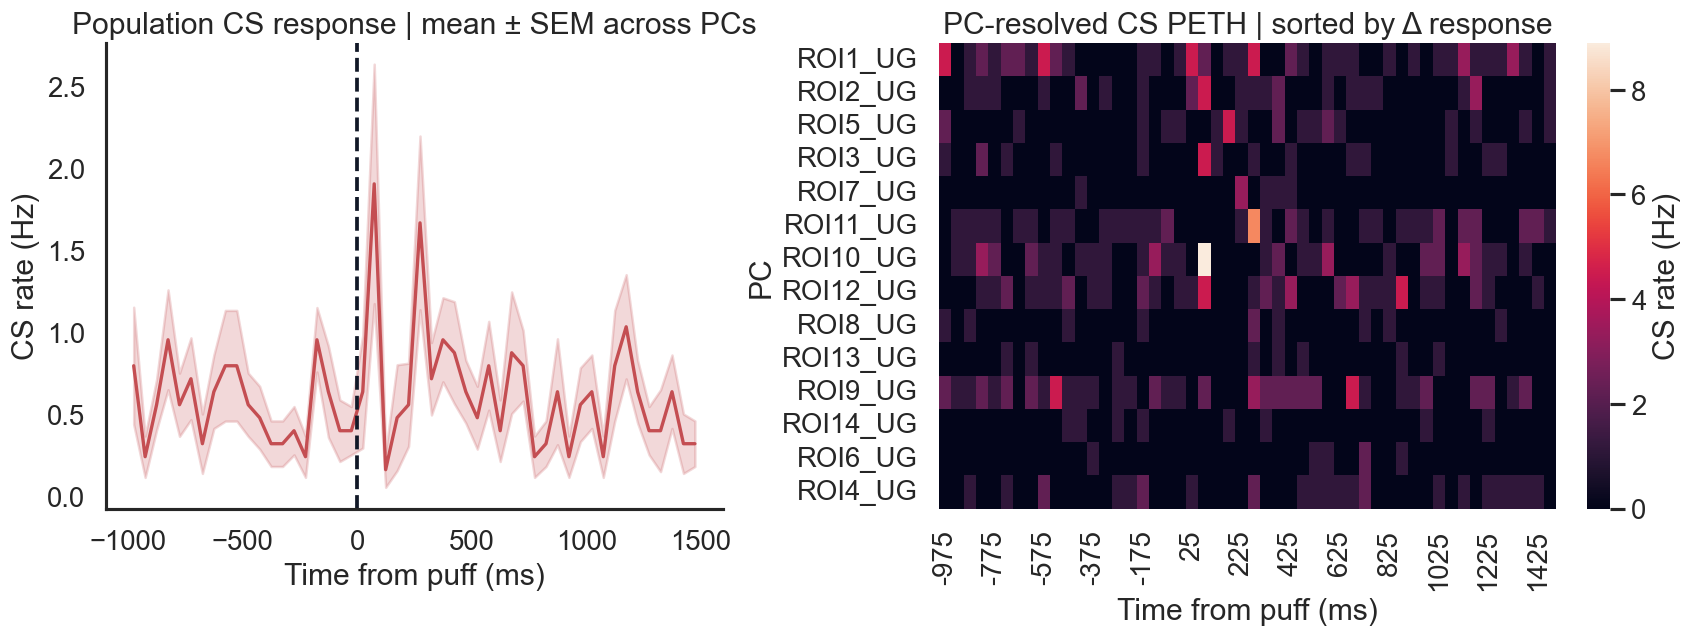

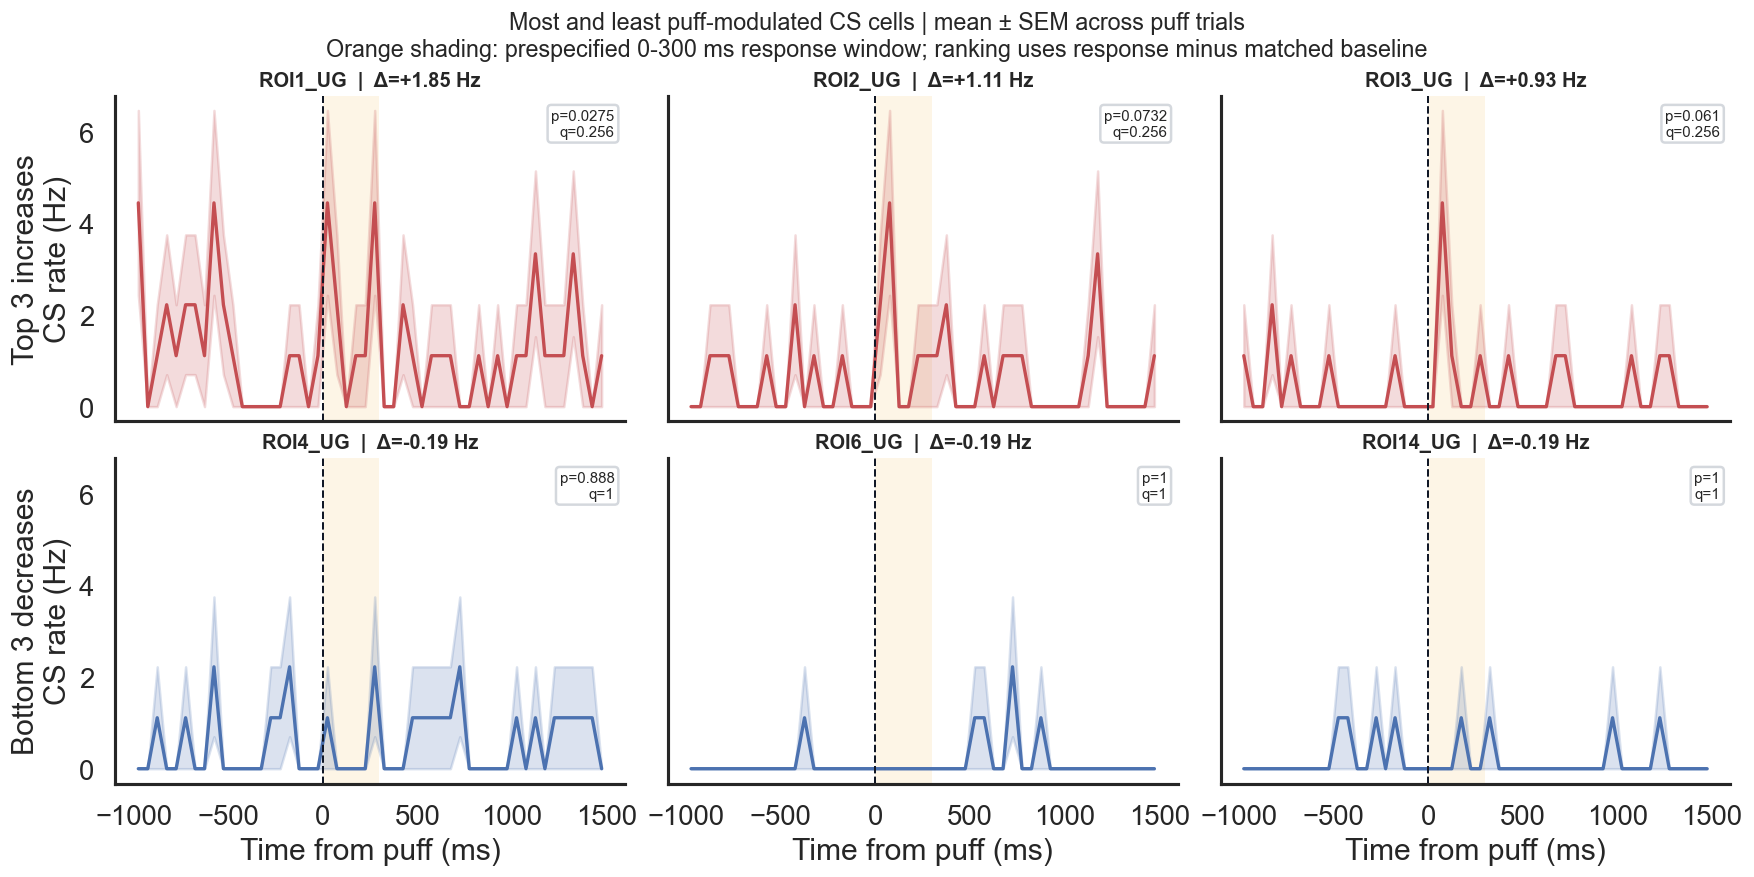

In [5]:
# ==============================
# CELL-LEVEL PUFF MODULATION: CS
# ==============================
def _bh_fdr(p_values):
    p = np.asarray(p_values, float); q = np.full_like(p, np.nan); valid = np.isfinite(p)
    if not np.any(valid): return q
    pv = p[valid]; order = np.argsort(pv); ranked = pv[order]
    adjusted = ranked * len(ranked) / np.arange(1, len(ranked) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]; adjusted = np.clip(adjusted, 0, 1)
    restored = np.empty_like(adjusted); restored[order] = adjusted; q[valid] = restored
    return q

def _paired_signflip_p(differences, n_permutations, rng):
    d = np.asarray(differences, float); d = d[np.isfinite(d)]
    if len(d) < 3: return np.nan
    observed = float(np.mean(d)); null = np.empty(int(n_permutations), float)
    for idx in range(int(n_permutations)): null[idx] = np.mean(d * rng.choice([-1.0, 1.0], size=len(d)))
    return (1.0 + np.sum(np.abs(null) >= abs(observed))) / (len(null) + 1.0)

rng = np.random.default_rng(int(STATS_CONFIG['rng_seed']))
cs_cell_rows = []
for cell, name in enumerate(cell_names):
    base_rate = cs_baseline_counts[:, cell] / cs_base_window_s
    response_rate = cs_response_counts[:, cell] / cs_window_s
    diff = response_rate - base_rate
    cs_cell_rows.append({'cell': name, 'baseline_rate_hz': np.mean(base_rate), 'response_rate_hz': np.mean(response_rate),
                         'delta_rate_hz': np.mean(diff), 'response_probability': np.mean(cs_response_counts[:, cell] > 0),
                         'signflip_p': _paired_signflip_p(diff, STATS_CONFIG['n_sign_flips'], rng)})
cs_cell_df = pd.DataFrame(cs_cell_rows); cs_cell_df['q'] = _bh_fdr(cs_cell_df['signflip_p'])
cs_order = np.argsort(cs_cell_df['delta_rate_hz'].to_numpy())[::-1]
display_top(cs_cell_df, label='Cell-level puff CS modulation', sort_by='delta_rate_hz')

bins = np.arange(PUFF_CONFIG['aligned_window_ms'][0], PUFF_CONFIG['aligned_window_ms'][1] + PUFF_CONFIG['peth_bin_ms'], PUFF_CONFIG['peth_bin_ms'])
centers = bins[:-1] + 0.5 * PUFF_CONFIG['peth_bin_ms']; cs_peth = np.zeros((n_trials, n_cells, len(centers)))
trial_cursor = 0
for s in processed_sessions:
    for event_ms in s['puff_times_ms']:
        if trial_cursor >= n_trials: break
        for cell, spikes in enumerate(s['spike_times_cs']):
            rel = spikes - event_ms; cs_peth[trial_cursor, cell], _ = np.histogram(rel, bins=bins)
        trial_cursor += 1
cs_peth_hz = cs_peth / (PUFF_CONFIG['peth_bin_ms'] / 1000.0)
mean_cell_peth = np.mean(cs_peth_hz, axis=0); pop_mean = np.mean(mean_cell_peth, axis=0)
pop_sem = np.std(mean_cell_peth, axis=0, ddof=1) / np.sqrt(n_cells)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), constrained_layout=True)
axes[0].plot(centers, pop_mean, color='#C44E52', lw=2); axes[0].fill_between(centers, pop_mean-pop_sem, pop_mean+pop_sem, color='#C44E52', alpha=.22)
axes[0].axvline(0, color='#111827', ls='--'); axes[0].set(xlabel='Time from puff (ms)', ylabel='CS rate (Hz)', title='Population CS response | mean ± SEM across PCs')
sns.heatmap(mean_cell_peth[cs_order], ax=axes[1], cmap='rocket', xticklabels=[f'{x:g}' if i % 4 == 0 else '' for i,x in enumerate(centers)],
            yticklabels=[cell_names[i] for i in cs_order], cbar_kws={'label':'CS rate (Hz)'})
axes[1].set(xlabel='Time from puff (ms)', ylabel='PC', title='PC-resolved CS PETH | sorted by Δ response')
plt.show(); plt.close(fig)


# Focused PETHs: the three largest increases and three largest decreases in the
# prespecified 0-300 ms response window. Ranking is descriptive; q values retain
# the full 14-PC multiple-comparison correction.
ranked_cs = (cs_cell_df.assign(cell_index=np.arange(n_cells))
             .sort_values(['delta_rate_hz', 'cell_index'], ascending=[False, True], kind='stable'))
top_three = ranked_cs.head(min(3, n_cells))
bottom_three = ranked_cs.tail(min(3, n_cells)).sort_values(
    ['delta_rate_hz', 'cell_index'], ascending=[True, True], kind='stable')

fig, axes = plt.subplots(2, 3, figsize=(14.5, 7.2), sharex=True, sharey=True, constrained_layout=True)
groups = [('Top 3 increases', top_three, '#C44E52'), ('Bottom 3 decreases', bottom_three, '#4C72B0')]
for row, (group_label, group_df, color) in enumerate(groups):
    for col, (_, info) in enumerate(group_df.iterrows()):
        ax = axes[row, col]
        cell = int(info['cell_index'])
        trials = cs_peth_hz[:, cell, :]
        mean = np.nanmean(trials, axis=0)
        sem = np.nanstd(trials, axis=0, ddof=1) / np.sqrt(np.sum(np.isfinite(trials), axis=0))
        ax.axvspan(*PUFF_CONFIG['cs_response_ms'], color='#F59E0B', alpha=.10, lw=0)
        ax.plot(centers, mean, color=color, lw=2)
        ax.fill_between(centers, mean-sem, mean+sem, color=color, alpha=.20)
        ax.axvline(0, color='#111827', ls='--', lw=1.2)
        ax.set_title(f"{info['cell']}  |  Δ={info['delta_rate_hz']:+.2f} Hz", fontsize=12, weight='bold')
        ax.text(.98, .96, f"p={info['signflip_p']:.3g}\nq={info['q']:.3g}", transform=ax.transAxes,
                ha='right', va='top', fontsize=9,
                bbox={'boxstyle': 'round,pad=.25', 'facecolor': 'white', 'edgecolor': '#D1D5DB', 'alpha': .92})
        if col == 0:
            ax.set_ylabel(f'{group_label}\nCS rate (Hz)')
        if row == 1:
            ax.set_xlabel('Time from puff (ms)')
        sns.despine(ax=ax)
fig.suptitle('Most and least puff-modulated CS cells | mean ± SEM across puff trials\n'
             'Orange shading: prespecified 0-300 ms response window; ranking uses response minus matched baseline',
             fontsize=14)
plt.show(); plt.close(fig)


Cell-level puff Vm modulation: showing 14 of 14 rows


,cell,vm_early_z,vm_late_z,early_signflip_p,late_signflip_p,early_q,late_q
9,ROI10_UG,0.966500,-0.007034,0.000100,0.806519,0.000280,0.955204
1,ROI2_UG,0.835099,-0.047007,0.000100,0.536146,0.000280,0.955204
2,ROI3_UG,0.735684,-0.004446,0.000100,0.931707,0.000280,0.955204
6,ROI7_UG,0.720745,0.031739,0.000100,0.490451,0.000280,0.955204
12,ROI13_UG,0.628066,-0.090515,0.000300,0.165983,0.000700,0.955204
7,ROI8_UG,0.571501,0.101416,0.000100,0.189781,0.000280,0.955204
5,ROI6_UG,0.500565,-0.063758,0.000400,0.307469,0.000700,0.955204
3,ROI4_UG,0.494844,-0.028602,0.000400,0.730027,0.000700,0.955204
0,ROI1_UG,0.471229,-0.028011,0.000700,0.642636,0.001089,0.955204
10,ROI11_UG,0.447477,-0.037949,0.005899,0.570543,0.008259,0.955204


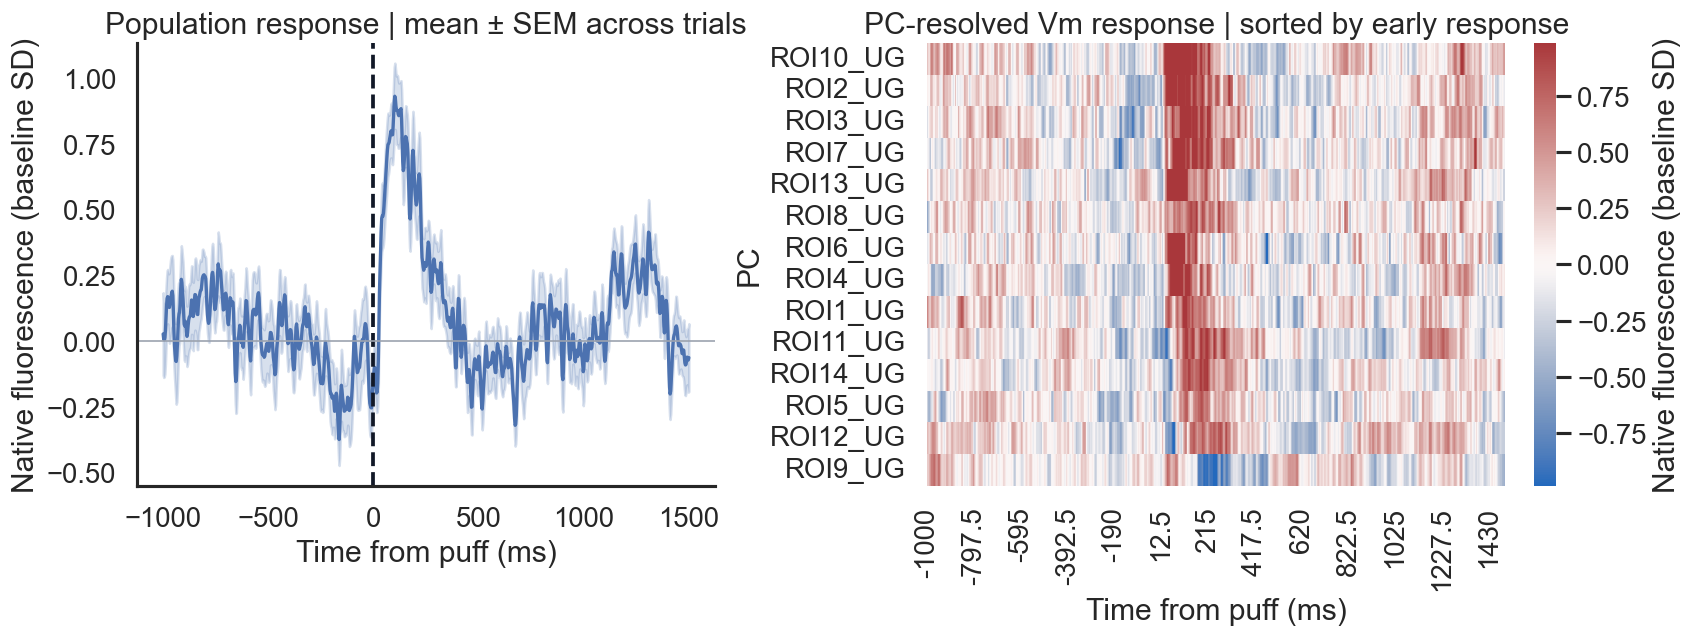

In [6]:
# ==============================
# CELL-LEVEL PUFF MODULATION: Vm
# ==============================
vm_cell_rows = []
for cell, name in enumerate(cell_names):
    early = vm_early_response[:, cell]; late = vm_late_response[:, cell]
    vm_cell_rows.append({'cell': name, 'vm_early_z': np.mean(early), 'vm_late_z': np.mean(late),
                         'early_signflip_p': _paired_signflip_p(early, STATS_CONFIG['n_sign_flips'], rng),
                         'late_signflip_p': _paired_signflip_p(late, STATS_CONFIG['n_sign_flips'], rng)})
vm_cell_df = pd.DataFrame(vm_cell_rows)
vm_cell_df['early_q'] = _bh_fdr(vm_cell_df['early_signflip_p']); vm_cell_df['late_q'] = _bh_fdr(vm_cell_df['late_signflip_p'])
vm_order = np.argsort(vm_cell_df['vm_early_z'].to_numpy())[::-1]
display_top(vm_cell_df, label='Cell-level puff Vm modulation', sort_by='vm_early_z')

mean_vm_cell = np.mean(vm_trial_z, axis=0).T
pop_trial_mean = np.mean(vm_trial_z, axis=2); pop_mean = np.mean(pop_trial_mean, axis=0)
pop_sem = np.std(pop_trial_mean, axis=0, ddof=1) / np.sqrt(n_trials)
vm_axis_label = ('Depolarizing-direction Vm proxy (baseline SD)' if VM_SIGN_MULTIPLIER < 0 and all_negative_going
                 else 'Native fluorescence (baseline SD)')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), constrained_layout=True)
axes[0].plot(aligned_grid_ms, pop_mean, color='#4C72B0', lw=2); axes[0].fill_between(aligned_grid_ms, pop_mean-pop_sem, pop_mean+pop_sem, color='#4C72B0', alpha=.22)
axes[0].axvline(0, color='#111827', ls='--'); axes[0].axhline(0, color='#9CA3AF', lw=1)
axes[0].set(xlabel='Time from puff (ms)', ylabel=vm_axis_label, title='Population response | mean ± SEM across trials')
vlim = max(0.5, float(np.nanpercentile(np.abs(mean_vm_cell), 98)))
sns.heatmap(mean_vm_cell[vm_order], ax=axes[1], cmap='vlag', center=0, vmin=-vlim, vmax=vlim,
            xticklabels=[f'{x:g}' if i % 75 == 0 else '' for i,x in enumerate(aligned_grid_ms)],
            yticklabels=[cell_names[i] for i in vm_order], cbar_kws={'label': vm_axis_label})
axes[1].set(xlabel='Time from puff (ms)', ylabel='PC', title='PC-resolved Vm response | sorted by early response')
plt.show(); plt.close(fig)


,period,metric,association,qap_p_two_sided
0,matched baseline,Pearson,0.070092,0.575242
1,matched baseline,Spearman,0.076225,0.544746
2,puff response,Pearson,0.173493,0.162684
3,puff response,Spearman,0.205722,0.112989


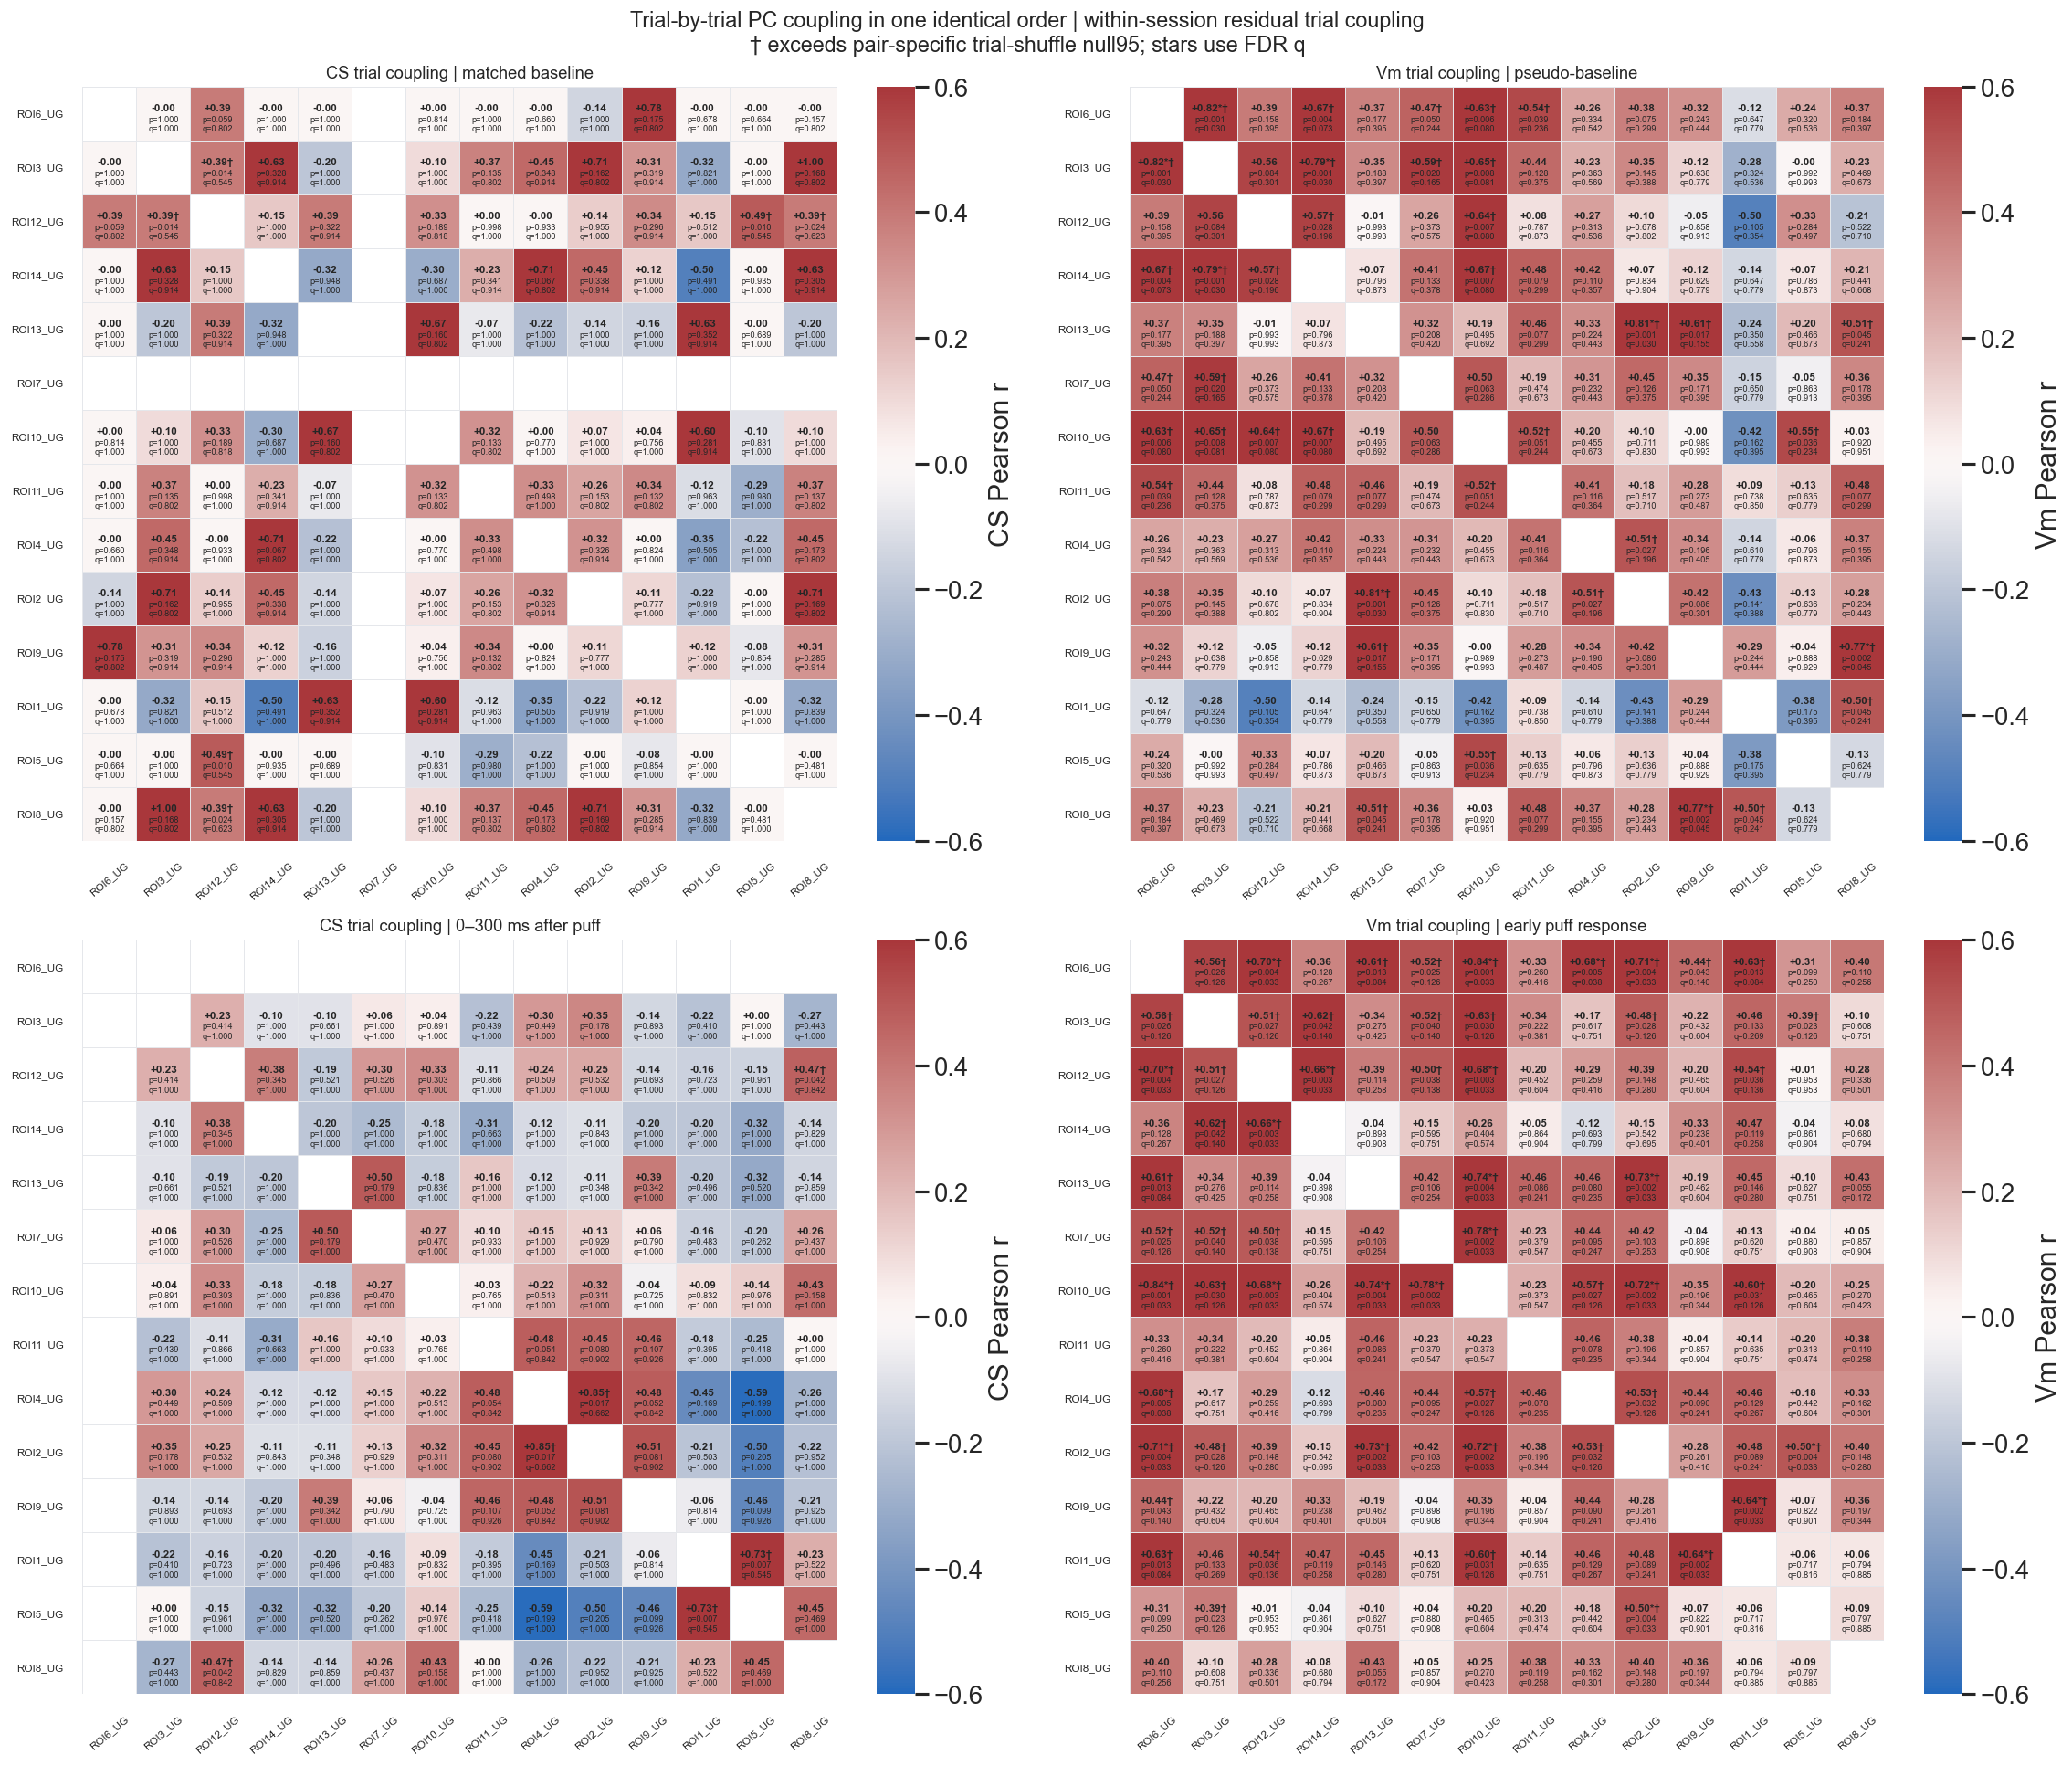

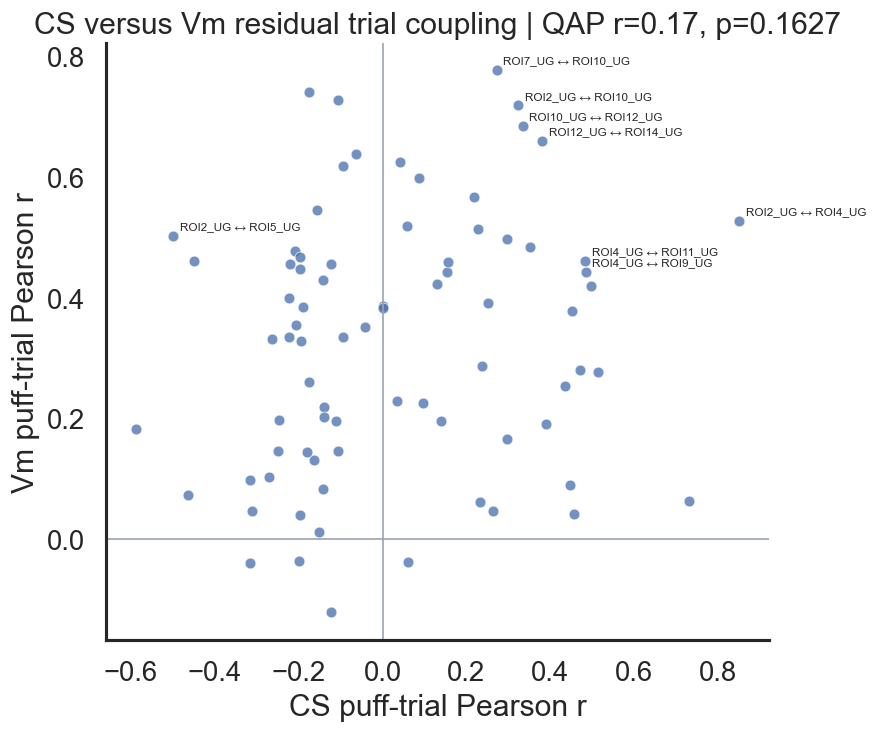

Strongest puff-response pairs: showing 14 of 91 rows


,cell_i,cell_j,cs_response_r,vm_response_r,cs_baseline_r,vm_baseline_r,pair,combined_abs_response
14,ROI2_UG,ROI4_UG,0.849837,0.526556,3.162278e-01,0.508467,ROI2_UG ↔ ROI4_UG,1.376392
65,ROI7_UG,ROI10_UG,0.271964,0.776614,NaN,0.498891,ROI7_UG ↔ ROI10_UG,1.048579
20,ROI2_UG,ROI10_UG,0.323575,0.718308,6.741999e-02,0.100046,ROI2_UG ↔ ROI10_UG,1.041884
89,ROI12_UG,ROI14_UG,0.381385,0.659192,1.543033e-01,0.567668,ROI12_UG ↔ ROI14_UG,1.040577
82,ROI10_UG,ROI12_UG,0.334497,0.684011,3.256695e-01,0.641555,ROI10_UG ↔ ROI12_UG,1.018508
15,ROI2_UG,ROI5_UG,-0.500000,0.502141,-1.404206e-33,0.131772,ROI2_UG ↔ ROI5_UG,1.002141
42,ROI4_UG,ROI11_UG,0.482805,0.460323,3.287980e-01,0.413696,ROI4_UG ↔ ROI11_UG,0.943127
40,ROI4_UG,ROI9_UG,0.484182,0.443190,1.006589e-17,0.336157,ROI4_UG ↔ ROI9_UG,0.927372
68,ROI7_UG,ROI13_UG,0.496139,0.419291,NaN,0.317681,ROI7_UG ↔ ROI13_UG,0.915430
83,ROI10_UG,ROI13_UG,-0.175412,0.739740,6.674238e-01,0.189077,ROI10_UG ↔ ROI13_UG,0.915151


In [7]:
# ==============================
# PAIRWISE TRIAL COUPLING AND CS–Vm QAP
# ==============================
def _safe_corr(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float); good = np.isfinite(x) & np.isfinite(y)
    if np.sum(good) < 4 or np.std(x[good]) <= 0 or np.std(y[good]) <= 0: return np.nan
    return float(np.corrcoef(x[good], y[good])[0, 1])

def _within_session_residualize(data):
    data = np.asarray(data, float); residual = data.copy()
    session_labels = trial_metadata_df['session'].astype(str).to_numpy()
    for label in np.unique(session_labels):
        rows = session_labels == label
        residual[rows] -= np.nanmean(residual[rows], axis=0, keepdims=True)
    return residual

def _permute_within_session(values, rng):
    values = np.asarray(values); shuffled = values.copy()
    labels = trial_metadata_df['session'].astype(str).to_numpy()
    for label in np.unique(labels):
        rows = np.flatnonzero(labels == label); shuffled[rows] = values[rng.permutation(rows)]
    return shuffled

def _pair_matrix_with_shuffle(data, n_shuffles, rng):
    data = np.asarray(data, float); corr = np.full((n_cells,n_cells), np.nan); p = np.full_like(corr,np.nan); null95=np.full_like(corr,np.nan)
    for i,j in combinations(range(n_cells),2):
        obs = _safe_corr(data[:,i], data[:,j]); null = np.asarray([_safe_corr(data[:,i], _permute_within_session(data[:,j], rng)) for _ in range(int(n_shuffles))])
        null = null[np.isfinite(null)]; pv=(1+np.sum(np.abs(null)>=abs(obs)))/(1+len(null)) if np.isfinite(obs) and len(null) else np.nan
        n95=float(np.percentile(np.abs(null),95)) if len(null) else np.nan
        corr[i,j]=corr[j,i]=obs; p[i,j]=p[j,i]=pv; null95[i,j]=null95[j,i]=n95
    q=np.full_like(p,np.nan); upper=np.triu_indices(n_cells,1); qvals=_bh_fdr(p[upper]); q[upper]=qvals; q[(upper[1],upper[0])]=qvals
    return corr,p,q,null95

def _qap_test(matrix_a, matrix_b, n_permutations, rng):
    upper=np.triu_indices(n_cells,1); x=matrix_a[upper]; y=matrix_b[upper]; good=np.isfinite(x)&np.isfinite(y); x=x[good]; y=y[good]
    obs_p=_safe_corr(x,y); obs_s=float(spearmanr(x,y).statistic) if len(x)>=3 else np.nan
    null_p=np.empty(int(n_permutations)); null_s=np.empty(int(n_permutations))
    for k in range(int(n_permutations)):
        perm=rng.permutation(n_cells); yp=matrix_b[np.ix_(perm,perm)][upper][good]
        null_p[k]=_safe_corr(x,yp); null_s[k]=spearmanr(x,yp).statistic
    return pd.DataFrame([
        {'metric':'Pearson','association':obs_p,'qap_p_two_sided':(1+np.sum(np.abs(null_p)>=abs(obs_p)))/(1+len(null_p))},
        {'metric':'Spearman','association':obs_s,'qap_p_two_sided':(1+np.sum(np.abs(null_s)>=abs(obs_s)))/(1+len(null_s))},
    ])

if bool(STATS_CONFIG['demean_trial_responses_within_session']):
    cs_response_pair_data = _within_session_residualize(cs_response_counts)
    cs_baseline_pair_data = _within_session_residualize(cs_baseline_counts)
    vm_response_pair_data = _within_session_residualize(vm_early_response)
    vm_baseline_pair_data = _within_session_residualize(vm_pseudo_baseline)
    pair_source_label = 'within-session residual trial coupling'
else:
    cs_response_pair_data, cs_baseline_pair_data = cs_response_counts, cs_baseline_counts
    vm_response_pair_data, vm_baseline_pair_data = vm_early_response, vm_pseudo_baseline
    pair_source_label = 'raw pooled-trial coupling'
cs_response_corr,cs_response_p,cs_response_q,cs_response_null95=_pair_matrix_with_shuffle(cs_response_pair_data,STATS_CONFIG['n_pair_trial_shuffles'],rng)
cs_baseline_corr,cs_baseline_p,cs_baseline_q,cs_baseline_null95=_pair_matrix_with_shuffle(cs_baseline_pair_data,STATS_CONFIG['n_pair_trial_shuffles'],rng)
vm_response_corr,vm_response_p,vm_response_q,vm_response_null95=_pair_matrix_with_shuffle(vm_response_pair_data,STATS_CONFIG['n_pair_trial_shuffles'],rng)
vm_baseline_corr,vm_baseline_p,vm_baseline_q,vm_baseline_null95=_pair_matrix_with_shuffle(vm_baseline_pair_data,STATS_CONFIG['n_pair_trial_shuffles'],rng)
qap_response = _qap_test(cs_response_corr, vm_response_corr, STATS_CONFIG['n_qap_permutations'], rng); qap_response.insert(0,'period','puff response')
qap_baseline = _qap_test(cs_baseline_corr, vm_baseline_corr, STATS_CONFIG['n_qap_permutations'], rng); qap_baseline.insert(0,'period','matched baseline')
qap_summary = pd.concat([qap_baseline,qap_response],ignore_index=True); display(qap_summary)

def _matrix_order(matrix):
    similarity=np.clip(np.nan_to_num(matrix,nan=0.0),-1,1); np.fill_diagonal(similarity,1)
    dist=np.sqrt(np.maximum(0,2*(1-similarity))); np.fill_diagonal(dist,0); condensed=squareform(dist,checks=False)
    tree=optimal_leaf_ordering(linkage(condensed,method='average'),condensed); return leaves_list(tree).astype(int)

def _stars(q):
    if not np.isfinite(q): return ''
    return '***' if q<.001 else '**' if q<.01 else '*' if q<.05 else ''

def plot_corr_matrix(matrix,p,q,null95,title,order,ax,cbar_label):
    shown=matrix[np.ix_(order,order)]; labels=[cell_names[i] for i in order]; mask=np.eye(n_cells,dtype=bool)
    sns.heatmap(shown,mask=mask,ax=ax,cmap='vlag',center=0,vmin=CORR_HEATMAP_SCALE['vmin'],vmax=CORR_HEATMAP_SCALE['vmax'],square=True,
                xticklabels=labels,yticklabels=labels,cbar_kws={'label':cbar_label},linewidths=.4,linecolor='#E5E7EB')
    for row,i in enumerate(order):
        for col,j in enumerate(order):
            if i==j or not np.isfinite(matrix[i,j]): continue
            dagger='†' if np.isfinite(null95[i,j]) and abs(matrix[i,j])>null95[i,j] else ''
            ax.text(col+.5,row+.40,f'{matrix[i,j]:+.2f}{_stars(q[i,j])}{dagger}',ha='center',va='center',fontsize=7,fontweight='bold')
            ax.text(col+.5,row+.69,f'p={p[i,j]:.3f}\nq={q[i,j]:.3f}',ha='center',va='center',fontsize=5.5)
    ax.set_title(title,fontsize=11); ax.tick_params(axis='x',rotation=40,labelsize=7); ax.tick_params(axis='y',labelsize=7)

order=_matrix_order(0.5*(cs_response_corr+vm_response_corr))
fig,axes=plt.subplots(2,2,figsize=(19,16),constrained_layout=True)
plot_corr_matrix(cs_baseline_corr,cs_baseline_p,cs_baseline_q,cs_baseline_null95,'CS trial coupling | matched baseline',order,axes[0,0],'CS Pearson r')
plot_corr_matrix(vm_baseline_corr,vm_baseline_p,vm_baseline_q,vm_baseline_null95,'Vm trial coupling | pseudo-baseline',order,axes[0,1],'Vm Pearson r')
plot_corr_matrix(cs_response_corr,cs_response_p,cs_response_q,cs_response_null95,'CS trial coupling | 0–300 ms after puff',order,axes[1,0],'CS Pearson r')
plot_corr_matrix(vm_response_corr,vm_response_p,vm_response_q,vm_response_null95,'Vm trial coupling | early puff response',order,axes[1,1],'Vm Pearson r')
fig.suptitle(f'Trial-by-trial PC coupling in one identical order | {pair_source_label}\n† exceeds pair-specific trial-shuffle null95; stars use FDR q',fontsize=14)
plt.show(); plt.close(fig)

upper=np.triu_indices(n_cells,1); pair_df=pd.DataFrame({'cell_i':[cell_names[i] for i in upper[0]],'cell_j':[cell_names[j] for j in upper[1]],
    'cs_response_r':cs_response_corr[upper],'vm_response_r':vm_response_corr[upper],
    'cs_baseline_r':cs_baseline_corr[upper],'vm_baseline_r':vm_baseline_corr[upper]})
pair_df['pair']=pair_df['cell_i']+' ↔ '+pair_df['cell_j']; pair_df['combined_abs_response']=np.abs(pair_df['cs_response_r'])+np.abs(pair_df['vm_response_r'])
qap_p=float(qap_response.loc[qap_response.metric=='Pearson','qap_p_two_sided'].iloc[0]); qap_r=float(qap_response.loc[qap_response.metric=='Pearson','association'].iloc[0])
fig,ax=plt.subplots(figsize=(7.2,6),constrained_layout=True)
ax.scatter(pair_df['cs_response_r'],pair_df['vm_response_r'],s=42,alpha=.78,color='#4C72B0',edgecolor='white',linewidth=.5)
for row in pair_df.nlargest(OUTPUT_CONFIG['scatter_label_top_n'],'combined_abs_response').itertuples(index=False):
    ax.annotate(row.pair,(row.cs_response_r,row.vm_response_r),xytext=(4,4),textcoords='offset points',fontsize=7)
ax.axhline(0,color='#9CA3AF',lw=1); ax.axvline(0,color='#9CA3AF',lw=1)
ax.set(xlabel='CS puff-trial Pearson r',ylabel='Vm puff-trial Pearson r',title=f'CS versus Vm residual trial coupling | QAP r={qap_r:.2f}, p={qap_p:.4g}')
sns.despine(ax=ax); plt.show(); plt.close(fig)
display_top(pair_df,label='Strongest puff-response pairs',sort_by='combined_abs_response')


## Joint baseline + puff-evoked clustering

This section creates **separate CS and Vm cluster solutions**. For each signal, it combines two complementary pairwise maps:

- **Baseline:** whole-recording coupling after excluding the configured interval around every puff. CS uses binned spike counts; Vm uses the CS/SS-blanked subthreshold trace.
- **Puff-evoked:** within-session residual trial coupling in the 0–300 ms response window. This asks whether two PCs fluctuate together from puff to puff, beyond recording-level shifts.

The two matrices are standardized across PC pairs before weighting, so the weights express intended influence. Hierarchical average-linkage clustering tests candidate cluster counts `k=2…6`; the selected `k` maximizes silhouette while avoiding singleton clusters when possible. Bootstrap co-assignment reports stability: values near 1 mean a pair repeatedly remains together, near 0 means repeatedly separate, and intermediate values mean uncertain membership. These are exploratory modules, especially with only 18 puff trials.


Selected CS k=4 (silhouette=0.393); Vm k=4 (silhouette=0.283).


,k_requested,k_observed,silhouette,smallest_cluster,passes_min_size,signal
0,2,1,NaN,14,False,CS
1,3,2,0.299,3,True,CS
2,4,3,0.322,2,True,CS
3,5,4,0.393,2,True,CS
4,6,5,0.383,2,True,CS
5,2,1,NaN,14,False,Vm
6,3,2,0.231,4,True,Vm
7,4,2,0.231,4,True,Vm
8,5,3,0.232,2,True,Vm
9,6,4,0.283,2,True,Vm


,cell,CS_cluster,CS_within_cluster_coassignment,Vm_cluster,Vm_within_cluster_coassignment
0,ROI1_UG,CS4,0.763,Vm2,0.780
1,ROI2_UG,CS3,0.877,Vm4,0.861
2,ROI3_UG,CS3,0.771,Vm4,0.905
3,ROI4_UG,CS3,0.850,Vm4,0.848
4,ROI5_UG,CS4,0.780,Vm4,0.847
5,ROI6_UG,CS2,0.770,Vm4,0.905
6,ROI7_UG,CS2,0.770,Vm4,0.877
7,ROI8_UG,CS4,0.587,Vm1,0.698
8,ROI9_UG,CS3,0.823,Vm2,0.780
9,ROI10_UG,CS3,0.855,Vm4,0.905


Vm_cluster,Vm1,Vm2,Vm3,Vm4
CS_cluster,,,,
CS1,2,0,1,0
CS2,0,0,0,2
CS3,0,1,1,4
CS4,1,1,0,1


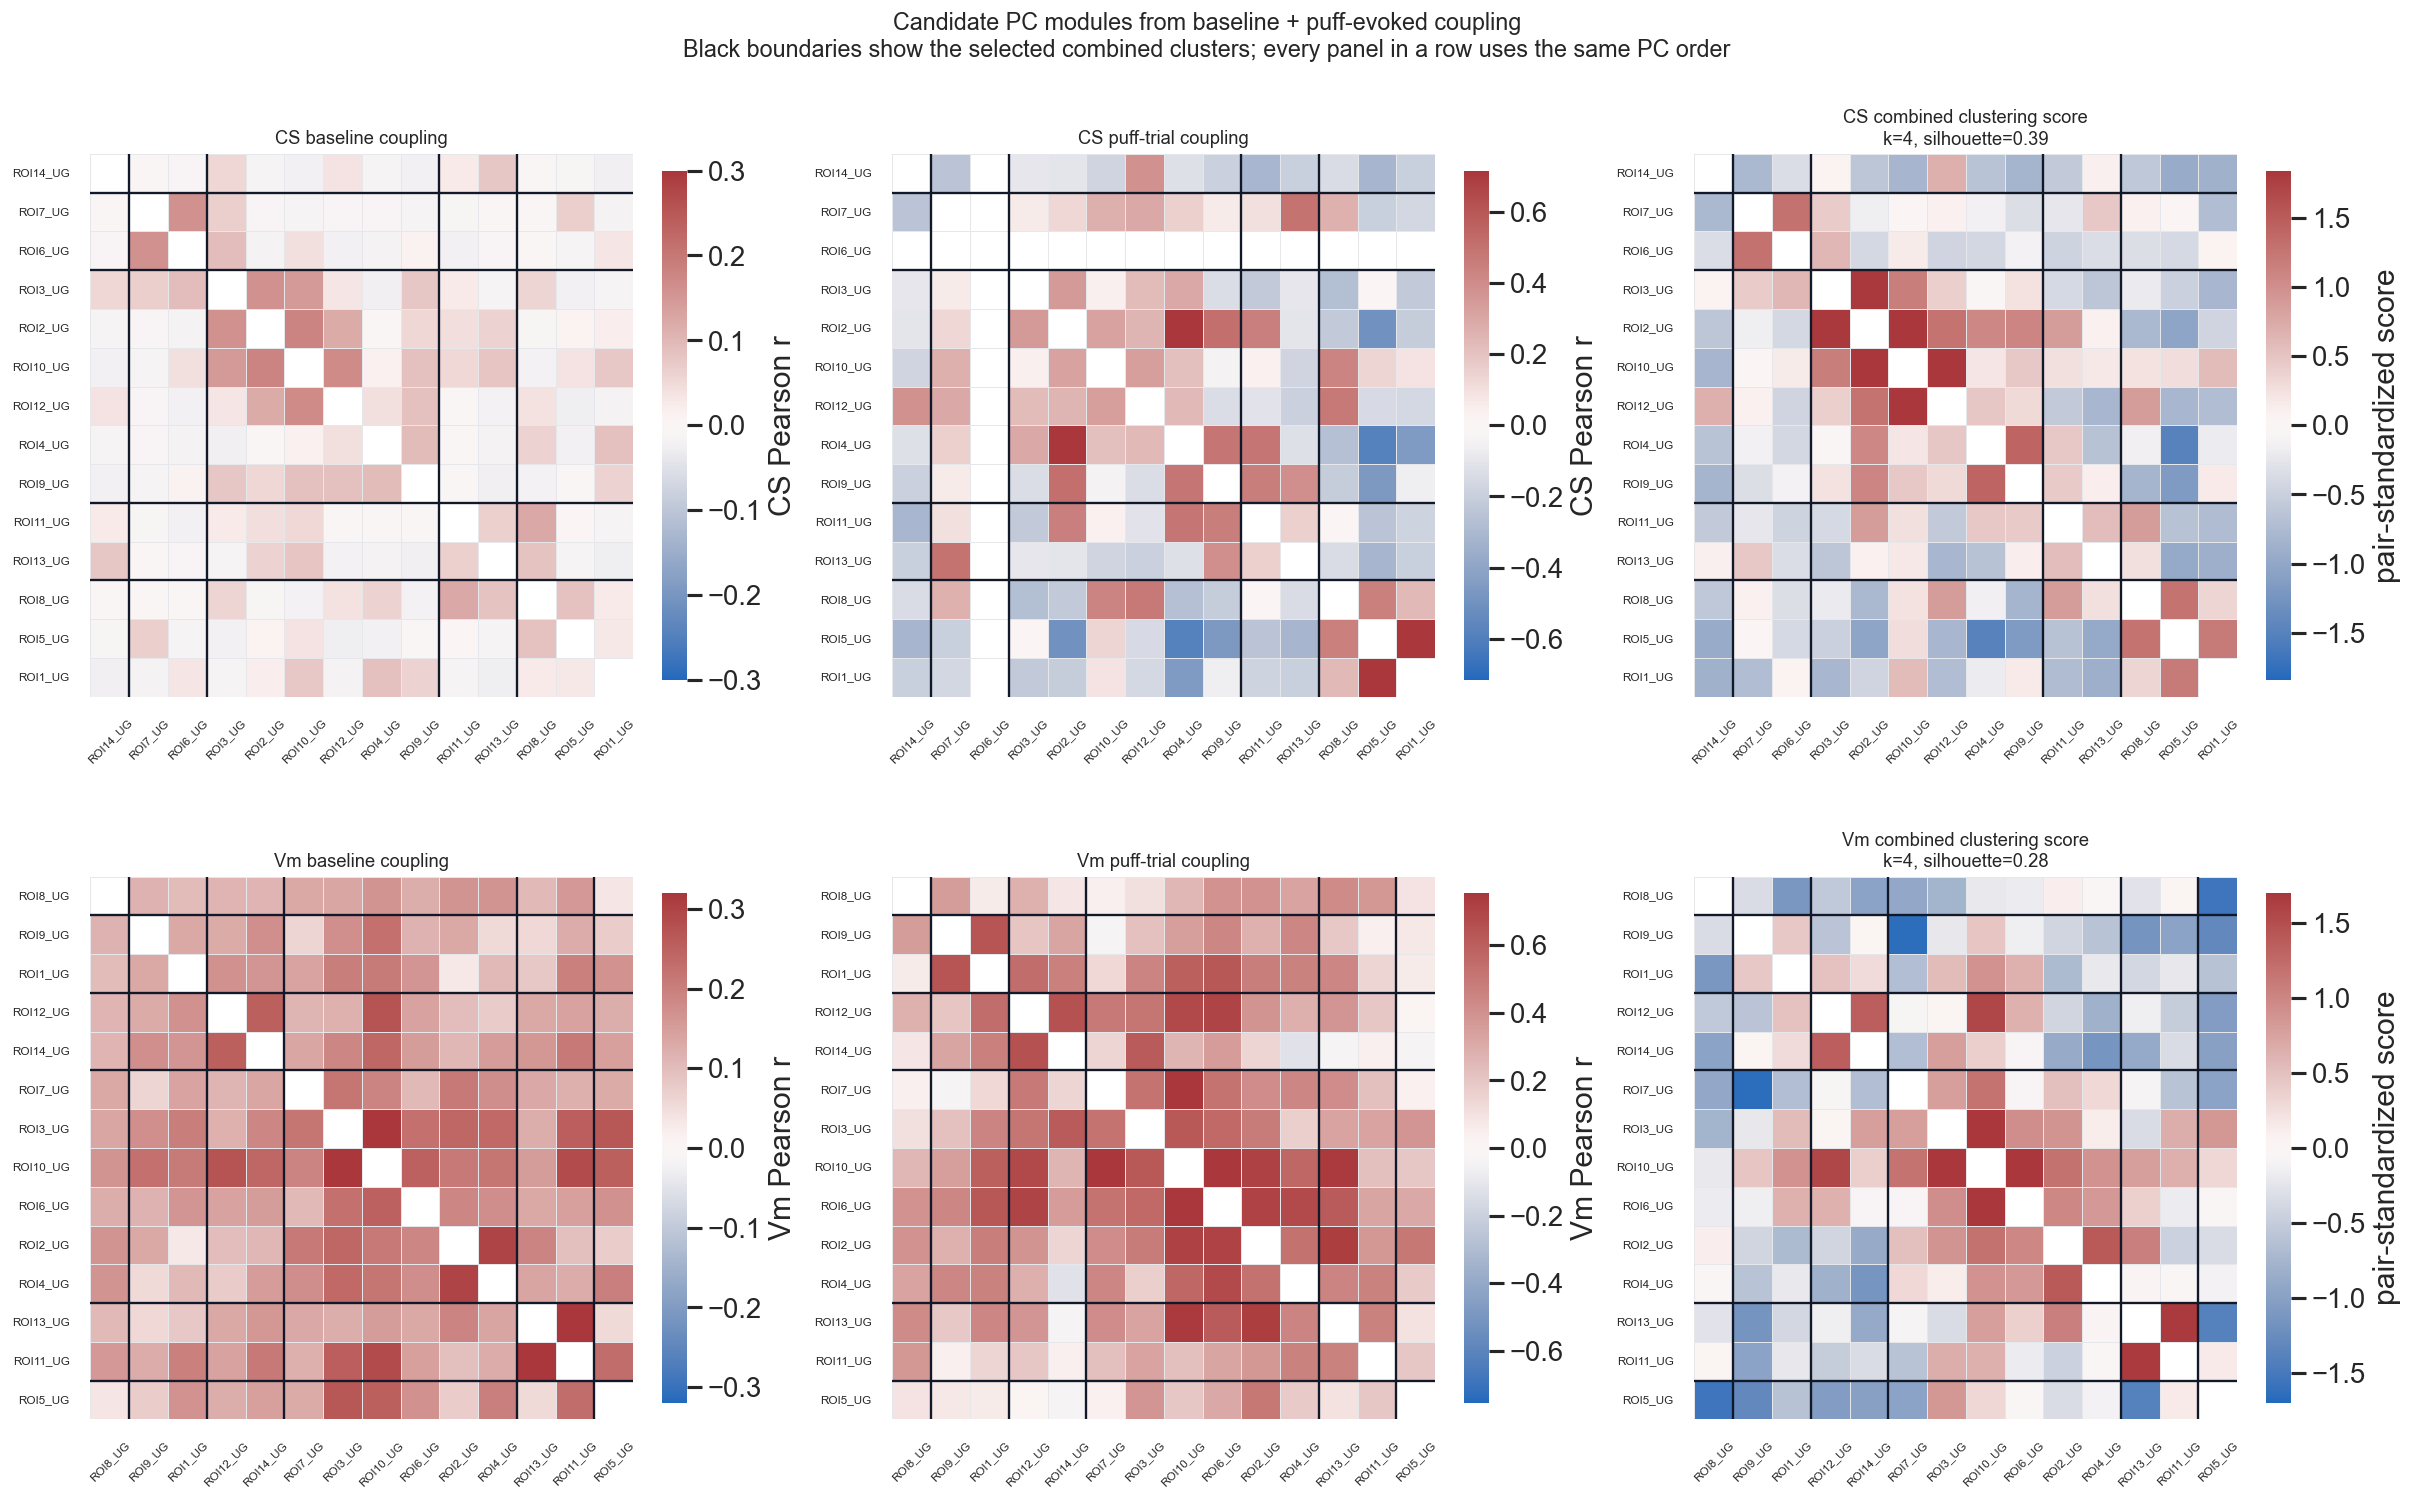

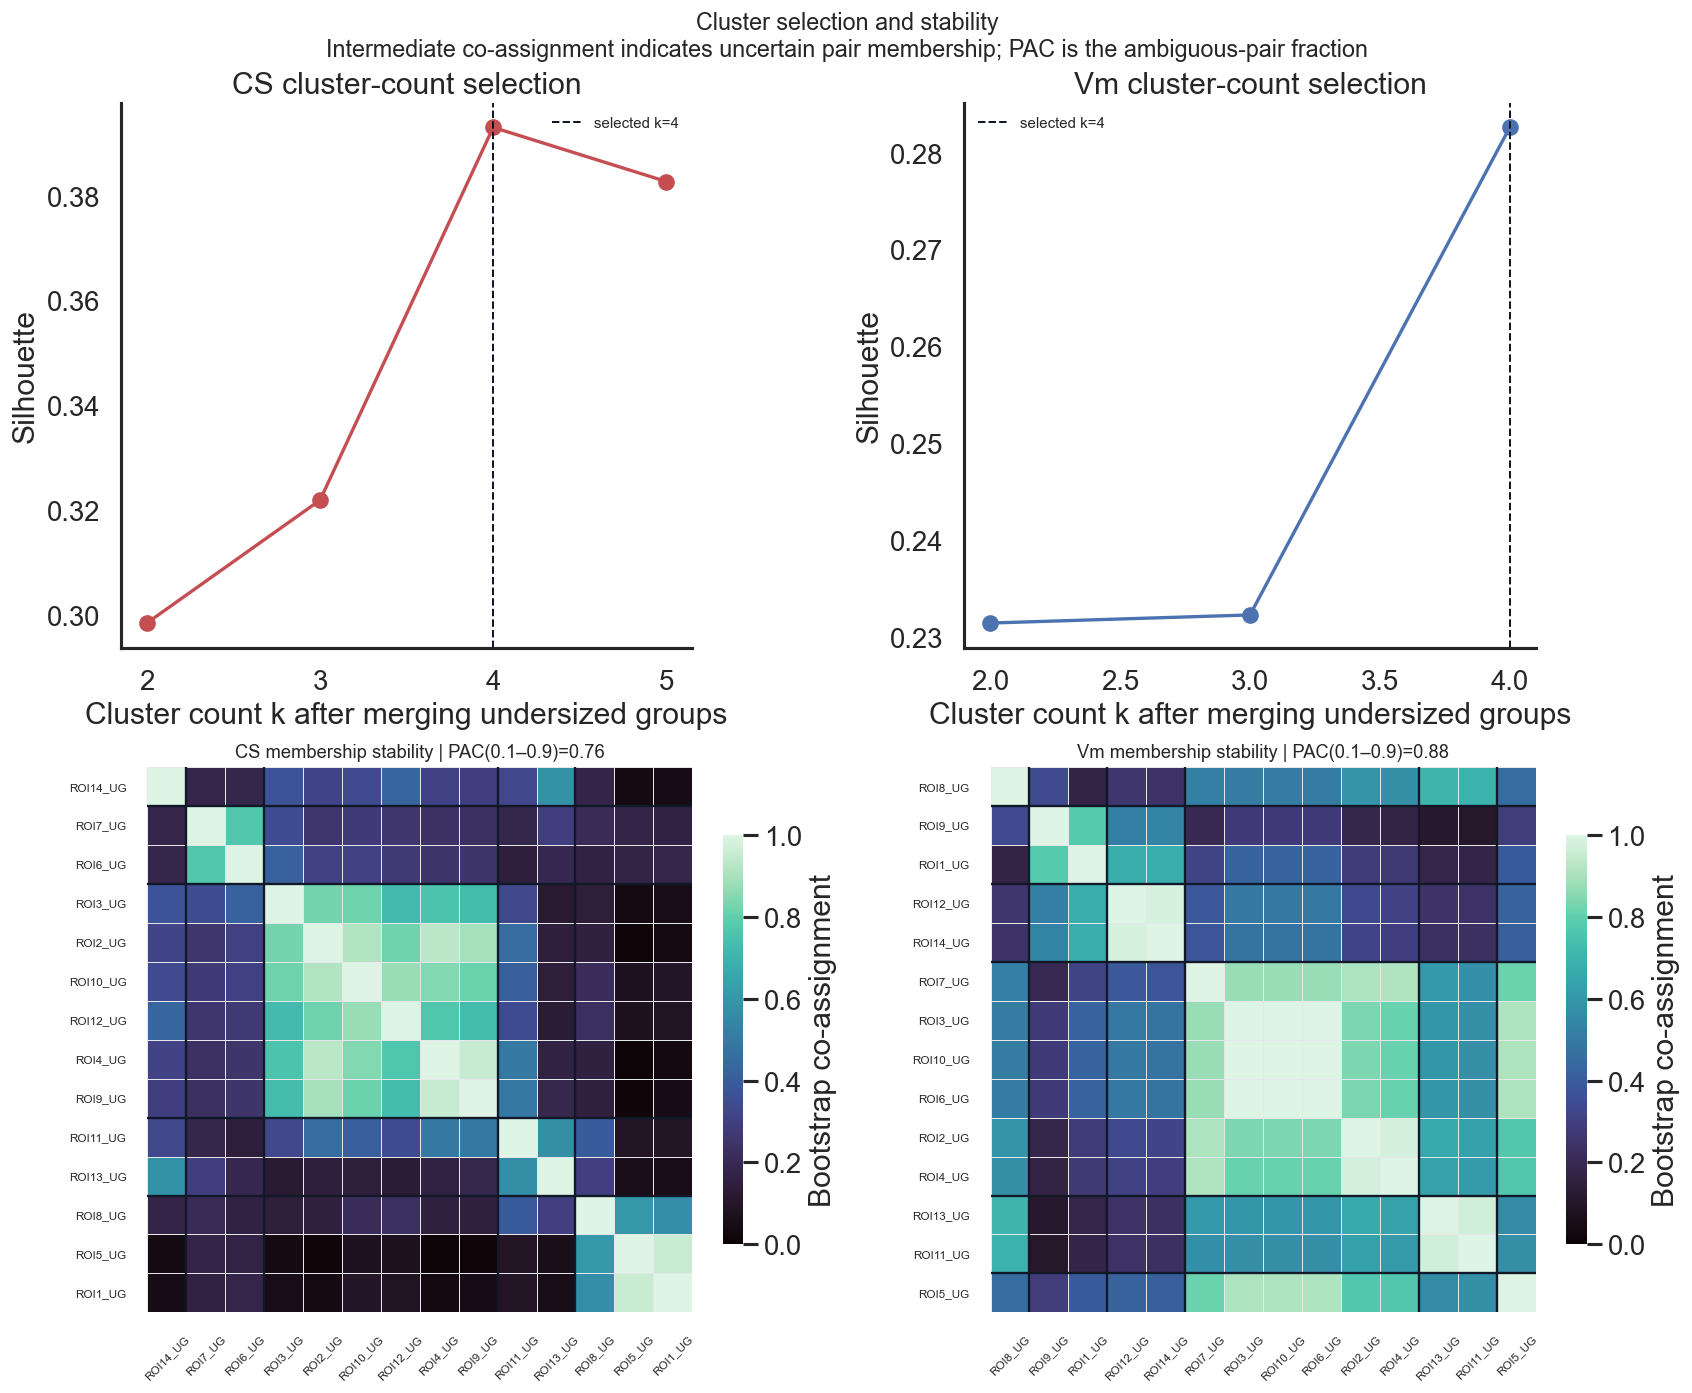

In [8]:
# ==============================
# COMBINED BASELINE + PUFF-EVOKED CLUSTERING
# ==============================
def _zscore_columns(values):
    values = np.asarray(values, float)
    mean = np.nanmean(values, axis=0, keepdims=True)
    sd = np.nanstd(values, axis=0, ddof=1, keepdims=True)
    sd[~np.isfinite(sd) | (sd <= 1e-12)] = 1.0
    out = (values - mean) / sd
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)

def _corr_from_features(features):
    features = np.asarray(features, float)
    matrix = np.eye(n_cells, dtype=float)
    for i, j in combinations(range(n_cells), 2):
        value = _safe_corr(features[:, i], features[:, j])
        matrix[i, j] = matrix[j, i] = value
    return matrix

def _whole_recording_baseline_features():
    cs_parts, cs_labels, vm_parts, vm_labels = [], [], [], []
    exclude = CLUSTER_CONFIG['baseline_exclude_around_puff_ms']
    cs_bin_ms = float(CLUSTER_CONFIG['baseline_cs_bin_ms'])
    vm_sample_ms = float(CLUSTER_CONFIG['baseline_vm_sample_ms'])
    for session_index, s in enumerate(processed_sessions):
        # CS counts in fixed bins, retaining only bins outside every puff-exclusion window.
        edges = np.arange(s['time_ms'][0], s['time_ms'][-1] + cs_bin_ms, cs_bin_ms)
        centers_here = edges[:-1] + 0.5 * cs_bin_ms
        valid_cs = np.ones(len(centers_here), dtype=bool)
        for onset in s['puff_times_ms']:
            valid_cs &= ~((centers_here >= onset + exclude[0]) & (centers_here < onset + exclude[1]))
        counts = np.column_stack([np.histogram(spikes, bins=edges)[0] for spikes in s['spike_times_cs']])
        if np.sum(valid_cs) >= 10:
            cs_parts.append(_zscore_columns(counts[valid_cs]))
            cs_labels.extend([session_index] * int(np.sum(valid_cs)))

        # Vm has already undergone bleaching correction, CS/SS blanking/interpolation, and low-pass filtering.
        valid_vm = np.ones(len(s['time_ms']), dtype=bool)
        for onset in s['puff_times_ms']:
            valid_vm &= ~((s['time_ms'] >= onset + exclude[0]) & (s['time_ms'] < onset + exclude[1]))
        sample_step = max(1, int(round(vm_sample_ms * s['fs'] / 1000.0)))
        rows = np.flatnonzero(valid_vm)[::sample_step]
        if len(rows) >= 10:
            vm_parts.append(_zscore_columns(s['subthreshold'][rows]))
            vm_labels.extend([session_index] * len(rows))
    if not cs_parts or not vm_parts:
        raise ValueError('Too little puff-free baseline data for combined clustering.')
    return (np.vstack(cs_parts), np.asarray(cs_labels, int),
            np.vstack(vm_parts), np.asarray(vm_labels, int))

def _pair_standardize(matrix):
    matrix = np.asarray(matrix, float)
    upper = np.triu_indices(n_cells, 1)
    values = matrix[upper]
    finite = np.isfinite(values)
    center = float(np.nanmean(values[finite])) if np.any(finite) else 0.0
    scale = float(np.nanstd(values[finite], ddof=1)) if np.sum(finite) > 1 else 1.0
    if not np.isfinite(scale) or scale <= 1e-12:
        scale = 1.0
    standardized = np.zeros_like(matrix, dtype=float)
    standardized[:] = (np.nan_to_num(matrix, nan=center) - center) / scale
    standardized = 0.5 * (standardized + standardized.T)
    np.fill_diagonal(standardized, 0.0)
    return standardized

def _combined_score(baseline_matrix, puff_matrix):
    wb = float(CLUSTER_CONFIG['baseline_weight']); wp = float(CLUSTER_CONFIG['puff_weight'])
    if wb < 0 or wp < 0 or wb + wp <= 0:
        raise ValueError('Clustering weights must be nonnegative and not both zero.')
    wb, wp = wb / (wb + wp), wp / (wb + wp)
    return wb * _pair_standardize(baseline_matrix) + wp * _pair_standardize(puff_matrix)

def _score_to_distance(score):
    score = np.asarray(score, float)
    upper = np.triu_indices(n_cells, 1)
    finite_values = score[upper][np.isfinite(score[upper])]
    ceiling = float(np.max(finite_values)) if len(finite_values) else 0.0
    distance = ceiling - np.nan_to_num(score, nan=float(np.nanmean(finite_values)) if len(finite_values) else 0.0)
    distance = np.maximum(0.0, 0.5 * (distance + distance.T))
    np.fill_diagonal(distance, 0.0)
    return distance

def _silhouette_precomputed(distance, labels):
    distance = np.asarray(distance, float); labels = np.asarray(labels, int)
    unique = np.unique(labels); values = []
    if len(unique) < 2 or len(unique) >= len(labels):
        return np.nan
    for i in range(len(labels)):
        same = np.flatnonzero(labels == labels[i]); same = same[same != i]
        if len(same) == 0:
            values.append(0.0); continue
        a = float(np.mean(distance[i, same]))
        b = min(float(np.mean(distance[i, labels == other])) for other in unique if other != labels[i])
        values.append((b - a) / max(a, b, 1e-12))
    return float(np.mean(values))

def _renumber_by_order(labels, order):
    labels = np.asarray(labels, int); mapping = {}; next_label = 1
    for index in order:
        value = int(labels[index])
        if value not in mapping:
            mapping[value] = next_label; next_label += 1
    return np.asarray([mapping[int(value)] for value in labels], int)

def _merge_small_clusters(labels, distance, min_size):
    """Merge undersized groups into the closest remaining group by mean pair distance."""
    labels = np.asarray(labels, int).copy()
    while True:
        unique, counts = np.unique(labels, return_counts=True)
        small = unique[counts < int(min_size)]
        if len(small) == 0 or len(unique) <= 1:
            break
        source = int(small[np.argmin([np.sum(labels == value) for value in small])])
        members = np.flatnonzero(labels == source)
        targets = [int(value) for value in unique if value != source]
        target = min(targets, key=lambda value: float(np.mean(distance[np.ix_(members, np.flatnonzero(labels == value))])))
        labels[members] = target
    return labels

def _cluster_combined_score(score, fixed_k=None):
    distance = _score_to_distance(score)
    condensed = squareform(distance, checks=False)
    tree = linkage(condensed, method=CLUSTER_CONFIG['linkage_method'])
    ordered_tree = optimal_leaf_ordering(tree, condensed)
    order = leaves_list(ordered_tree).astype(int)
    rows = []
    k_values = [int(fixed_k)] if fixed_k is not None else range(
        max(2, int(CLUSTER_CONFIG['k_min'])), min(int(CLUSTER_CONFIG['k_max']), n_cells - 1) + 1)
    candidates = []
    for k in k_values:
        labels = fcluster(tree, t=k, criterion='maxclust').astype(int)
        labels = _merge_small_clusters(labels, distance, CLUSTER_CONFIG['min_cluster_size'])
        unique_labels, sizes = np.unique(labels, return_counts=True); actual_k = len(unique_labels)
        silhouette = _silhouette_precomputed(distance, labels)
        valid_size = bool(actual_k >= 2 and len(sizes) and np.min(sizes) >= int(CLUSTER_CONFIG['min_cluster_size']))
        rows.append({'k_requested': k, 'k_observed': actual_k, 'silhouette': silhouette,
                     'smallest_cluster': int(np.min(sizes)) if len(sizes) else 0,
                     'passes_min_size': valid_size})
        candidates.append((valid_size, silhouette, k, labels))
    valid = [item for item in candidates if item[0] and np.isfinite(item[1])]
    pool = valid if valid else [item for item in candidates if np.isfinite(item[1])]
    chosen = max(pool, key=lambda item: item[1]) if pool else candidates[0]
    labels = _renumber_by_order(chosen[3], order)
    return {'labels': labels, 'k': len(np.unique(labels)), 'silhouette': float(chosen[1]),
            'order': order, 'distance': distance, 'diagnostics': pd.DataFrame(rows)}

def _block_bootstrap_rows(values, session_labels, block_rows, rng):
    values = np.asarray(values, float); session_labels = np.asarray(session_labels)
    selected = []
    for label in np.unique(session_labels):
        rows = np.flatnonzero(session_labels == label); target = len(rows); picked = []
        while len(picked) < target:
            start = int(rng.integers(0, target))
            picked.extend(rows[(start + np.arange(block_rows)) % target].tolist())
        selected.extend(picked[:target])
    return values[np.asarray(selected, int)]

def _trial_bootstrap_rows(values, rng):
    values = np.asarray(values, float); labels = trial_metadata_df['session'].astype(str).to_numpy(); selected = []
    for label in np.unique(labels):
        rows = np.flatnonzero(labels == label)
        selected.extend(rng.choice(rows, size=len(rows), replace=True).tolist())
    return values[np.asarray(selected, int)]

def _combined_coassignment(baseline_features, baseline_labels, puff_features, observed, baseline_step_ms, rng):
    n_boot = int(CLUSTER_CONFIG['n_bootstrap']); coassign = np.zeros((n_cells, n_cells), float)
    block_rows = max(1, int(round(float(CLUSTER_CONFIG['bootstrap_block_ms']) / baseline_step_ms)))
    for _ in range(n_boot):
        boot_baseline = _block_bootstrap_rows(baseline_features, baseline_labels, block_rows, rng)
        boot_puff = _trial_bootstrap_rows(puff_features, rng)
        score = _combined_score(_corr_from_features(boot_baseline), _corr_from_features(boot_puff))
        labels = _cluster_combined_score(score, fixed_k=observed['k'])['labels']
        coassign += labels[:, None] == labels[None, :]
    coassign /= max(1, n_boot)
    return coassign

def _cluster_boundaries(ax, ordered_labels):
    boundaries = np.flatnonzero(np.diff(np.asarray(ordered_labels))) + 1
    for boundary in boundaries:
        ax.axhline(boundary, color='#111827', lw=1.4)
        ax.axvline(boundary, color='#111827', lw=1.4)

baseline_cs_features, baseline_cs_sessions, baseline_vm_features, baseline_vm_sessions = _whole_recording_baseline_features()
cs_whole_baseline_corr = _corr_from_features(baseline_cs_features)
vm_whole_baseline_corr = _corr_from_features(baseline_vm_features)
cs_combined_score = _combined_score(cs_whole_baseline_corr, cs_response_corr)
vm_combined_score = _combined_score(vm_whole_baseline_corr, vm_response_corr)
cs_cluster = _cluster_combined_score(cs_combined_score)
vm_cluster = _cluster_combined_score(vm_combined_score)

cluster_rng = np.random.default_rng(int(CLUSTER_CONFIG['rng_seed']))
cs_coassignment = _combined_coassignment(
    baseline_cs_features, baseline_cs_sessions, cs_response_pair_data, cs_cluster,
    float(CLUSTER_CONFIG['baseline_cs_bin_ms']), cluster_rng)
vm_coassignment = _combined_coassignment(
    baseline_vm_features, baseline_vm_sessions, vm_response_pair_data, vm_cluster,
    float(CLUSTER_CONFIG['baseline_vm_sample_ms']), cluster_rng)

def _cluster_stability(coassignment, labels, cell):
    peers = np.flatnonzero(labels == labels[cell]); peers = peers[peers != cell]
    return float(np.mean(coassignment[cell, peers])) if len(peers) else np.nan

combined_cluster_df = pd.DataFrame({
    'cell': cell_names,
    'CS_cluster': [f'CS{value}' for value in cs_cluster['labels']],
    'CS_within_cluster_coassignment': [_cluster_stability(cs_coassignment, cs_cluster['labels'], i) for i in range(n_cells)],
    'Vm_cluster': [f'Vm{value}' for value in vm_cluster['labels']],
    'Vm_within_cluster_coassignment': [_cluster_stability(vm_coassignment, vm_cluster['labels'], i) for i in range(n_cells)],
})
cluster_diagnostics_df = pd.concat([
    cs_cluster['diagnostics'].assign(signal='CS'), vm_cluster['diagnostics'].assign(signal='Vm')
], ignore_index=True)
cluster_overlap_df = pd.crosstab(combined_cluster_df['CS_cluster'], combined_cluster_df['Vm_cluster'])
print(f"Selected CS k={cs_cluster['k']} (silhouette={cs_cluster['silhouette']:.3f}); "
      f"Vm k={vm_cluster['k']} (silhouette={vm_cluster['silhouette']:.3f}).")
display(cluster_diagnostics_df.round(3)); display(combined_cluster_df.round(3)); display(cluster_overlap_df)

# Baseline, puff, and combined evidence shown in the same cluster-derived order.
fig, axes = plt.subplots(2, 3, figsize=(20, 12.5), constrained_layout=True)
rows = [
    ('CS', cs_cluster, cs_whole_baseline_corr, cs_response_corr, cs_combined_score),
    ('Vm', vm_cluster, vm_whole_baseline_corr, vm_response_corr, vm_combined_score),
]
for row, (signal, result, baseline_matrix, puff_matrix, combined_matrix) in enumerate(rows):
    order = result['order']; labels = [cell_names[i] for i in order]; ordered_clusters = result['labels'][order]
    for col, (matrix, title, color_label, is_score) in enumerate([
        (baseline_matrix, f'{signal} baseline coupling', f'{signal} Pearson r', False),
        (puff_matrix, f'{signal} puff-trial coupling', f'{signal} Pearson r', False),
        (combined_matrix, f'{signal} combined clustering score', 'pair-standardized score', True),
    ]):
        shown = matrix[np.ix_(order, order)]; mask = np.eye(n_cells, dtype=bool)
        if is_score:
            limit = max(1.0, float(np.nanpercentile(np.abs(shown[~mask]), 98)))
        else:
            limit = max(0.3, float(np.nanpercentile(np.abs(shown[~mask]), 98)))
        sns.heatmap(shown, mask=mask, ax=axes[row, col], cmap='vlag', center=0,
                    vmin=-limit, vmax=limit, square=True, xticklabels=labels, yticklabels=labels,
                    linewidths=.35, linecolor='#E5E7EB', cbar_kws={'label': color_label, 'shrink': .72})
        _cluster_boundaries(axes[row, col], ordered_clusters)
        axes[row, col].set_title(title + (f"\nk={result['k']}, silhouette={result['silhouette']:.2f}" if is_score else ''), fontsize=11)
        axes[row, col].tick_params(axis='x', rotation=45, labelsize=7); axes[row, col].tick_params(axis='y', labelsize=7)
fig.suptitle('Candidate PC modules from baseline + puff-evoked coupling\n'
             'Black boundaries show the selected combined clusters; every panel in a row uses the same PC order', fontsize=14)
plt.show(); plt.close(fig)

# Selection diagnostics and bootstrap stability.
fig, axes = plt.subplots(2, 2, figsize=(14, 11.5), constrained_layout=True)
for col, (signal, result, coassignment) in enumerate([('CS', cs_cluster, cs_coassignment), ('Vm', vm_cluster, vm_coassignment)]):
    diagnostic = result['diagnostics']
    diagnostic_plot = (diagnostic.loc[diagnostic['passes_min_size'] & np.isfinite(diagnostic['silhouette'])]
                       .groupby('k_observed', as_index=False)['silhouette'].max().sort_values('k_observed'))
    axes[0, col].plot(diagnostic_plot['k_observed'], diagnostic_plot['silhouette'], marker='o', lw=2,
                      color=['#C44E52', '#4C72B0'][col])
    axes[0, col].axvline(result['k'], color='#111827', ls='--', lw=1.2, label=f"selected k={result['k']}")
    axes[0, col].set(xlabel='Cluster count k after merging undersized groups', ylabel='Silhouette',
                     title=f'{signal} cluster-count selection')
    axes[0, col].legend(frameon=False, fontsize=9); sns.despine(ax=axes[0, col])

    order = result['order']; shown = coassignment[np.ix_(order, order)]; ordered_clusters = result['labels'][order]
    sns.heatmap(shown, ax=axes[1, col], cmap='mako', vmin=0, vmax=1, square=True,
                xticklabels=[cell_names[i] for i in order], yticklabels=[cell_names[i] for i in order],
                linewidths=.35, linecolor='#E5E7EB', cbar_kws={'label': 'Bootstrap co-assignment', 'shrink': .75})
    _cluster_boundaries(axes[1, col], ordered_clusters)
    upper_values = coassignment[np.triu_indices(n_cells, 1)]
    pac = float(np.mean((upper_values > 0.10) & (upper_values < 0.90)))
    axes[1, col].set_title(f'{signal} membership stability | PAC(0.1–0.9)={pac:.2f}', fontsize=11)
    axes[1, col].tick_params(axis='x', rotation=45, labelsize=7); axes[1, col].tick_params(axis='y', labelsize=7)
fig.suptitle('Cluster selection and stability\nIntermediate co-assignment indicates uncertain pair membership; PAC is the ambiguous-pair fraction', fontsize=14)
plt.show(); plt.close(fig)


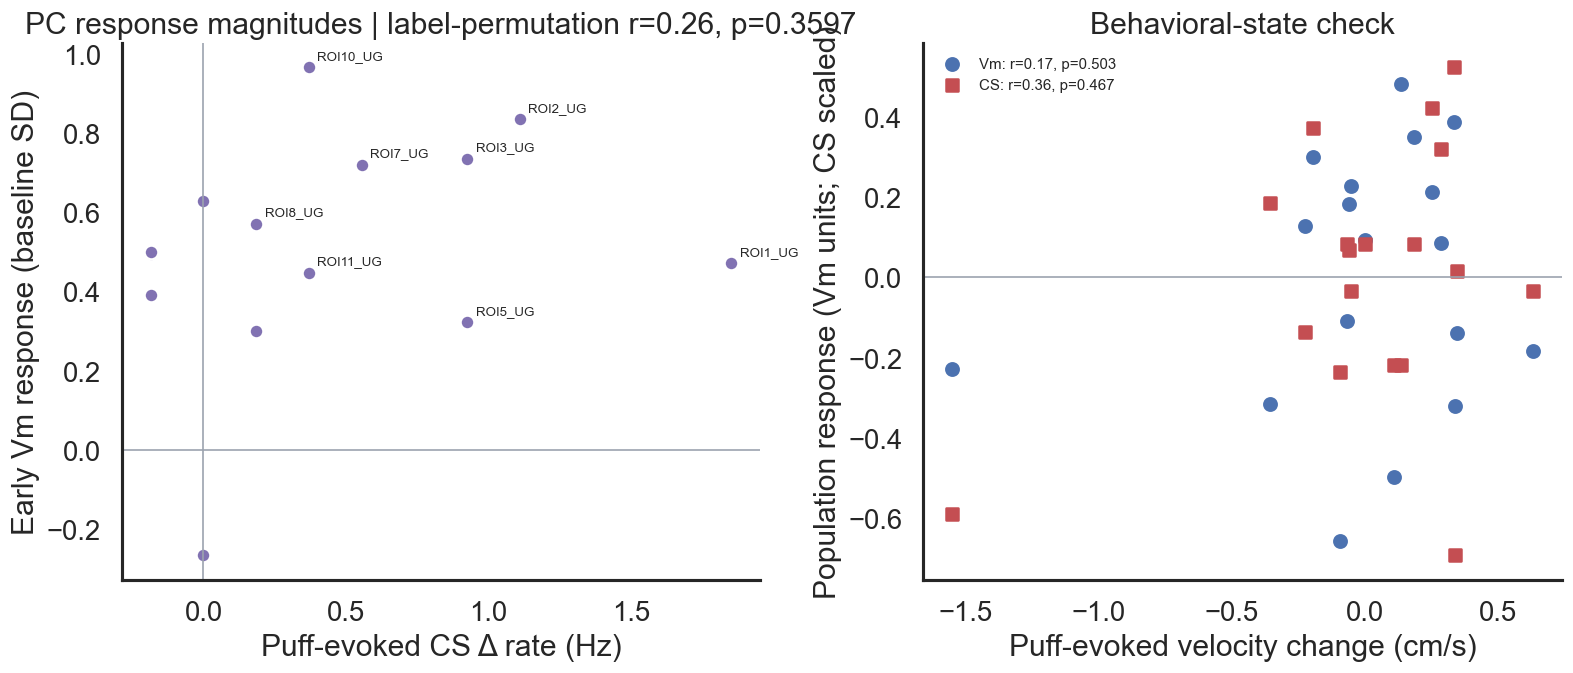

,cell,baseline_rate_hz,response_rate_hz,delta_rate_hz,response_probability,signflip_p,q,vm_early_z,vm_late_z,early_signflip_p,late_signflip_p,early_q,late_q,label_score
0,ROI1_UG,0.3704,2.2222,1.8519,0.5556,0.0275,0.2562,0.4712,-0.0280,0.0007,0.6426,0.0011,0.9552,2.3231
1,ROI2_UG,0.3704,1.4815,1.1111,0.4444,0.0732,0.2562,0.8351,-0.0470,0.0001,0.5361,0.0003,0.9552,1.9462
2,ROI3_UG,0.1852,1.1111,0.9259,0.3333,0.0610,0.2562,0.7357,-0.0044,0.0001,0.9317,0.0003,0.9552,1.6616
4,ROI5_UG,0.1852,1.1111,0.9259,0.3333,0.0643,0.2562,0.3215,-0.0241,0.0231,0.6813,0.0294,0.9552,1.2475
6,ROI7_UG,0.0000,0.5556,0.5556,0.1667,0.2475,0.6929,0.7207,0.0317,0.0001,0.4905,0.0003,0.9552,1.2763
9,ROI10_UG,1.1111,1.4815,0.3704,0.4444,0.5529,1.0000,0.9665,-0.0070,0.0001,0.8065,0.0003,0.9552,1.3369
10,ROI11_UG,0.9259,1.2963,0.3704,0.3333,0.4962,1.0000,0.4475,-0.0379,0.0059,0.5705,0.0083,0.9552,0.8178
7,ROI8_UG,0.1852,0.3704,0.1852,0.1111,1.0000,1.0000,0.5715,0.1014,0.0001,0.1898,0.0003,0.9552,0.7567
11,ROI12_UG,0.9259,1.1111,0.1852,0.3333,0.9013,1.0000,0.2991,0.0213,0.0809,0.7908,0.0809,0.9552,0.4843
8,ROI9_UG,0.9259,0.9259,0.0000,0.2778,1.0000,1.0000,-0.2665,-0.0060,0.0270,0.9479,0.0313,0.9552,0.2665


In [9]:
# ==============================
# CELL RESPONSE CORRESPONDENCE AND BEHAVIORAL COVARIATE
# ==============================
cell_response_df = cs_cell_df.merge(vm_cell_df,on='cell')
def _label_permutation_corr(x,y,n,rng,within_session=False):
    obs=_safe_corr(x,y)
    if within_session:
        null=np.asarray([_safe_corr(x,_permute_within_session(y,rng)) for _ in range(int(n))])
    else:
        null=np.asarray([_safe_corr(x,np.asarray(y)[rng.permutation(len(y))]) for _ in range(int(n))])
    return obs,(1+np.sum(np.abs(null)>=abs(obs)))/(1+len(null))

cell_r,cell_p=_label_permutation_corr(cell_response_df['delta_rate_hz'].to_numpy(),cell_response_df['vm_early_z'].to_numpy(),STATS_CONFIG['n_qap_permutations'],rng)
fig,axes=plt.subplots(1,2,figsize=(13,5.5),constrained_layout=True)
axes[0].scatter(cell_response_df['delta_rate_hz'],cell_response_df['vm_early_z'],s=70,c='#8172B2',edgecolor='white')
cell_response_df['label_score'] = np.abs(cell_response_df['delta_rate_hz']) + np.abs(cell_response_df['vm_early_z'])
for row in cell_response_df.nlargest(int(OUTPUT_CONFIG['scatter_label_top_n']), 'label_score').itertuples(index=False):
    axes[0].annotate(row.cell,(row.delta_rate_hz,row.vm_early_z),xytext=(5,5),textcoords='offset points',fontsize=8)
axes[0].axhline(0,color='#9CA3AF',lw=1); axes[0].axvline(0,color='#9CA3AF',lw=1)
axes[0].set(xlabel='Puff-evoked CS Δ rate (Hz)',ylabel='Early Vm response (baseline SD)',title=f'PC response magnitudes | label-permutation r={cell_r:.2f}, p={cell_p:.4g}')

global_vm=np.mean(vm_early_response,axis=1); global_cs=np.mean(cs_delta_rate_trials,axis=1); velocity_delta=trial_metadata_df['velocity_delta_cm_s'].to_numpy()
if bool(STATS_CONFIG['demean_trial_responses_within_session']):
    global_vm=_within_session_residualize(global_vm[:,None])[:,0]; global_cs=_within_session_residualize(global_cs[:,None])[:,0]; velocity_delta=_within_session_residualize(velocity_delta[:,None])[:,0]
vm_vel_r,vm_vel_p=_label_permutation_corr(velocity_delta,global_vm,STATS_CONFIG['n_qap_permutations'],rng,within_session=True)
cs_vel_r,cs_vel_p=_label_permutation_corr(velocity_delta,global_cs,STATS_CONFIG['n_qap_permutations'],rng,within_session=True)
axes[1].scatter(velocity_delta,global_vm,s=55,label=f'Vm: r={vm_vel_r:.2f}, p={vm_vel_p:.3g}',color='#4C72B0')
scale=max(np.nanstd(global_cs),1e-9); cs_scaled=(global_cs-np.nanmean(global_cs))/scale*np.nanstd(global_vm)+np.nanmean(global_vm)
axes[1].scatter(velocity_delta,cs_scaled,s=55,marker='s',label=f'CS: r={cs_vel_r:.2f}, p={cs_vel_p:.3g}',color='#C44E52')
axes[1].axhline(0,color='#9CA3AF',lw=1); axes[1].set(xlabel='Puff-evoked velocity change (cm/s)',ylabel='Population response (Vm units; CS scaled)',title='Behavioral-state check'); axes[1].legend(frameon=False,fontsize=9)
for ax in axes: sns.despine(ax=ax)
plt.show(); plt.close(fig)
display(cell_response_df.sort_values('delta_rate_hz',ascending=False).round(4))


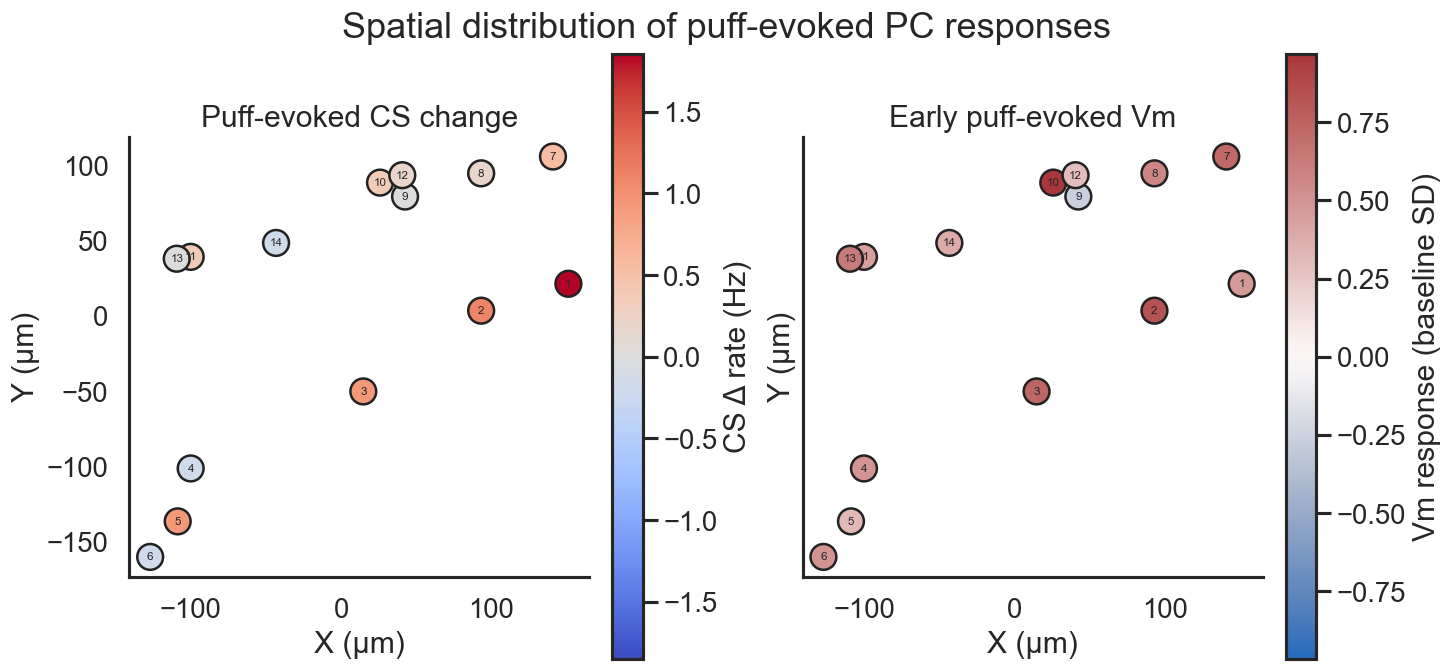

In [10]:
# ==============================
# OPTIONAL XY RESPONSE MAPS
# ==============================
def _normalize_roi(value):
    text=str(value).strip().upper().replace(' ',''); return text[:-3] if text.endswith('_UG') else text

coord_candidates=sorted(glob.glob(os.path.join(DATA_FOLDER,'*_roi_coords.csv')))
roi_coordinate_df=pd.DataFrame()
if coord_candidates:
    coords=pd.read_csv(coord_candidates[0]); normalized={_normalize_roi(c):c for c in cell_names}
    roi_col=next((c for c in coords.columns if str(c).strip().lower() in {'roi','cell','cell_name','roi_name'}),coords.columns[0])
    x_col=next((c for c in coords.columns if str(c).strip().lower() in {'x_um','x (um)','x_µm','x','center_um_x'}),None)
    y_col=next((c for c in coords.columns if str(c).strip().lower() in {'y_um','y (um)','y_µm','y','center_um_y'}),None)
    if x_col and y_col:
        rows=[]
        for row in coords.itertuples(index=False):
            data=row._asdict(); key=_normalize_roi(data[roi_col])
            if key in normalized: rows.append({'cell':normalized[key],'x':float(data[x_col]),'y':float(data[y_col])})
        roi_coordinate_df=pd.DataFrame(rows).set_index('cell').reindex(cell_names).reset_index()

if len(roi_coordinate_df)==n_cells and roi_coordinate_df[['x','y']].notna().all().all():
    fig,axes=plt.subplots(1,2,figsize=(12,5.6),sharex=True,sharey=True,constrained_layout=True)
    for ax,values,title,cmap,label in [
        (axes[0],cell_response_df.set_index('cell').loc[cell_names,'delta_rate_hz'].to_numpy(),'Puff-evoked CS change','coolwarm','CS Δ rate (Hz)'),
        (axes[1],cell_response_df.set_index('cell').loc[cell_names,'vm_early_z'].to_numpy(),'Early puff-evoked Vm','vlag','Vm response (baseline SD)')]:
        vmax=max(1e-9,float(np.nanmax(np.abs(values)))); sc=ax.scatter(roi_coordinate_df['x'],roi_coordinate_df['y'],c=values,cmap=cmap,vmin=-vmax,vmax=vmax,s=240,edgecolor='#222222')
        for idx,name in enumerate(cell_names): ax.text(roi_coordinate_df.loc[idx,'x'],roi_coordinate_df.loc[idx,'y'],re.sub(r'\D','',name),ha='center',va='center',fontsize=7)
        fig.colorbar(sc,ax=ax,label=label); ax.set(title=title,xlabel='X (µm)',ylabel='Y (µm)'); ax.set_aspect('equal')
    fig.suptitle('Spatial distribution of puff-evoked PC responses'); plt.show(); plt.close(fig)
else:
    print('No complete ROI coordinate table found; spatial puff-response maps skipped.')


In [11]:
# ==============================
# OPTIONAL EXPORT
# ==============================
def export_puff_results():
    os.makedirs(EXPORT_DIR,exist_ok=True)
    session_summary.to_csv(os.path.join(EXPORT_DIR,'session_puff_alignment.csv'),index=False)
    trial_metadata_df.to_csv(os.path.join(EXPORT_DIR,'puff_trial_metadata.csv'),index=False)
    cs_cell_df.to_csv(os.path.join(EXPORT_DIR,'cell_cs_puff_modulation.csv'),index=False)
    vm_cell_df.to_csv(os.path.join(EXPORT_DIR,'cell_vm_puff_modulation.csv'),index=False)
    cell_response_df.to_csv(os.path.join(EXPORT_DIR,'cell_cs_vm_puff_responses.csv'),index=False)
    pair_df.to_csv(os.path.join(EXPORT_DIR,'pair_cs_vm_puff_trial_coupling.csv'),index=False)
    qap_summary.to_csv(os.path.join(EXPORT_DIR,'puff_cs_vm_qap.csv'),index=False)
    combined_cluster_df.to_csv(os.path.join(EXPORT_DIR,'combined_baseline_puff_cluster_membership.csv'),index=False)
    cluster_diagnostics_df.to_csv(os.path.join(EXPORT_DIR,'combined_cluster_silhouette_diagnostics.csv'),index=False)
    cluster_overlap_df.to_csv(os.path.join(EXPORT_DIR,'combined_cs_vm_cluster_overlap.csv'))
    for name,matrix in [('cs_response',cs_response_corr),('cs_baseline_trial',cs_baseline_corr),
                        ('vm_response',vm_response_corr),('vm_baseline_trial',vm_baseline_corr),
                        ('cs_whole_baseline',cs_whole_baseline_corr),('vm_whole_baseline',vm_whole_baseline_corr),
                        ('cs_combined_score',cs_combined_score),('vm_combined_score',vm_combined_score),
                        ('cs_cluster_coassignment',cs_coassignment),('vm_cluster_coassignment',vm_coassignment)]:
        pd.DataFrame(matrix,index=cell_names,columns=cell_names).to_csv(os.path.join(EXPORT_DIR,f'{name}_correlation_matrix.csv'))
    print(f'Exported puff CS–Vm results to {EXPORT_DIR}')

if EXPORT_RESULTS: export_puff_results()
